# **BAB 1. Perkenalan**

<h2>Name: Florean Alexander    
<h2>Batch: RMT-053  

## **Background**

Dalam beberapa tahun terakhir, kondisi kesehatan suatu negara menjadi indikator penting dalam menilai tingkat kesejahteraan masyarakat. Salah satu indikator utama yang sering digunakan adalah **life expectancy (harapan hidup)**, yang dipengaruhi oleh berbagai faktor seperti kondisi kesehatan, akses layanan medis, sanitasi, dan faktor demografis.

Namun, tidak semua negara memiliki tingkat kesehatan yang sama. Perbedaan ini dipengaruhi oleh berbagai indikator seperti tingkat fertilitas, angka kematian, fasilitas kesehatan, hingga kondisi ekonomi. Oleh karena itu, diperlukan pendekatan berbasis data untuk memahami faktor-faktor yang memengaruhi kondisi kesehatan suatu negara.

## **Problem Statement**

Mengembangkan model *machine learning* untuk mengklasifikasikan **status kesehatan suatu negara (tinggi atau rendah)** berdasarkan berbagai indikator kesehatan dan populasi secara akurat. Keberhasilan model akan diukur menggunakan metrik evaluasi seperti **Precision dan ROC-AUC** dengan target performa tinggi (Precision & ROC-AUC > 0.9). Permasalahan ini dapat dicapai dengan memanfaatkan dataset indikator kesehatan global serta menerapkan proses preprocessing, feature engineering, dan algoritma seperti **Random Forest**. Solusi ini relevan karena dapat membantu dalam analisis kondisi kesehatan negara serta mendukung pengambilan keputusan berbasis data di sektor kesehatan. Pengembangan model dilakukan dalam satu siklus proyek dari tahap eksplorasi data hingga evaluasi model.

## **Objective**

- Mengembangkan model *machine learning* untuk mengklasifikasikan **status kesehatan suatu negara**.
- Mengidentifikasi hubungan antara indikator kesehatan dan life expectancy.
- Membandingkan performa beberapa model untuk mendapatkan model terbaik.
- Menghasilkan model yang dapat digunakan untuk prediksi data baru.

## **Dataset**

Dataset yang digunakan berisi berbagai negara, tahun, wilayah, kelompok ekonomi, indikator kesehatan dan populasi dari berbagai negara. Berikut kolom yang ada di dalam dataset:
- `country_name`: negara
- `indicator_name`: jenis indikator
- `value`: nilai indikator
- `year`: tahun
- `region`: wilayah
- `income_group`: kategori ekonomi

Kemudian dataset akan diextract lagi berdasarkan indicator_name, seperti:
- `Population growth`
- `Mortality rate`
- `Fertility rate`
- `Healthcare resources (physicians, hospital beds, dll)`
- `Sanitation & water access`
- `Nutrition indicators`
- `Life Expectancy`

Target utama dalam dataset ini adalah `Life Expectancy` yang akan diubah menjadi variabel klasifikasi `health_status` (0 = rendah, 1 = tinggi).

## **Algoritma**

1. **`K-Nearest Neighbors (KNN)`**    
Model berbasis jarak yang mengklasifikasikan data berdasarkan tetangga terdekat. KNN sederhana dan intuitif tetapi sensitif terhadap skala data dan performanya dapat menurun pada dataset besar.

2. **`Support Vector Machine (SVM)`**    
Model yang bekerja dengan mencari *hyperplane* terbaik untuk memisahkan kelas. SVM efektif pada data berdimensi tinggi tetapi sensitif terhadap pemilihan parameter dan *scaling* data.

3. **`Decision Tree`**    
Model non-linear yang mampu menangkap hubungan kompleks antar fitur dan mudah diinterpretasikan tetapi ini cenderung *overfitting* jika tidak dikontrol dengan baik.

4. **`Random Forest`**    
Model *ensemble* berbasis *decision tree* yang mampu menangkap hubungan non-linear antar fitur dan lebih stabil karena menggabungkan banyak pohon keputusan. Model ini juga relatif tahan terhadap *overfitting* dibandingkan *single decision tree*.

5. **Gradient Boosting**    
Model *ensemble* yang bekerja dengan memperbaiki kesalahan model sebelumnya secara bertahap tetapi lebih sensitif terhadap *noise* dan membutuhkan *tuning* yang baik.

Kelima algoritma diimplementasikan menggunakan pipeline untuk menggabungkan *preprocessing* dan *training model* dalam satu alur yang terstruktur sehingga memungkinkan perbandingan performa secara adil dalam proses pemilihan model terbaik.

---

Evaluasi Metrik:
1. **`Precision`**    
Metrik yang digunakan untuk mengukur seberapa akurat model dalam memprediksi kelas positif. Precision tinggi menunjukkan bahwa sebagian besar prediksi positif yang dihasilkan model adalah benar.

2. **`ROC-AUC Score`**    
Metrik yang digunakan untuk mengukur kemampuan model dalam membedakan antara kelas positif dan negatif secara keseluruhan.

## **Target User**

1. Kementerian Kesehatan Republik Indonesia     
Penggunaan untuk mengevaluasi kebijakan kesehatan nasional.
2. Organisasi kesehatan (WHO, NGO)    
Penggunaan untuk menganalisis kondisi kesehatan global.
3. Peneliti & akademisi     
Penggunaan untuk studi terkait kesehatan populasi.

# **BAB 2. Import Libraries**

Langkah pertama yang dilakukan untuk mengembangkan *Machine Learning* adalah **Import Libraries**. Langkah ini merupakan proses pemanggilan *package* atau *modules* berisi *function* yang dibutuhkan untuk menjalani program.

In [1]:
#from google.colab import auth
#from google.cloud import bigquery

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
import phik
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler 
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import precision_score, roc_auc_score

import pickle

import warnings
warnings.filterwarnings("ignore")

Berikut merupakan penjelasan dari *library* yang saya pakai:
- `google.colab.auth` digunakan untuk melakukan autentikasi akun Google agar bisa mengakses BigQuery.
- `google.cloud import bigquery` digunakan untuk mengakses dan menjalankan *query* SQL di Google BigQuery.
- `pandas` digunakan untuk membaca dan memproses dataset.
- `numpy` digunakan untuk operasi numerik dan manipulasi array.
- `seaborn` digunakan untuk membuat visualisasi data statistik.
- `matplotlib` digunakan bersama seaborn untuk menampilkan plot.
- `train_test_split` digunakan untuk membagi *dataset* menjadi *training set* dan *testing set*.
- `SimpleImputer` digunakan untuk mengisi *missing value*.
- `phik` digunakan sebagai metode korelasi yang bisa menangani data numerik dan data kategorikal.
- `MinMaxScaler` digunakan untuk menormalisasi data ke range 0–1 dengan nilai min dan max.
- `OneHotEncoder` digunakan untuk data kategori yang tidak memiliki urutan menjadi *binary matrix*.
- `OrdinalEncoder` digunakan untuk data kategori yang memiliki urutan menjadi *binary matrix*.
- `Pipeline` digunakan sebagai penggabungan *preprocessing* + model dalam satu alur.
- `KNeighborsClassifier` digunakan sebagai algoritma klasifikasi berbasis tetangga.
- `SVC` digunakan sebagai algoritma klasifikasi.
- `DecisionTreeClassifier` digunakan sebagai algoritma klasifikasi berbasis pohon.
- `RandomForestClassifier` digunakan sebagai algoritma klasifikasi.
- `GradientBoostingClassifier` digunakan sebagai algoritma klasifikasi.
- `cross_val_score` digunakan untuk melakukan validasi secara bertahap.
- `GridSearchCV` digunakan untuk mencari parameter terbaik model menggunakan cross-validation.
- `precision_score` digunakan untuk mengukur kemampuan menangkap kelas positif.
- `roc_auc_score` digunakan untuk mengukur kemampuan membedakan kelas.

- `pickle` digunakan untuk menyimpan model *Machine Learning* agar bisa digunakan kembali tanpa training ulang.
- `warnings` digunakan sebagai pencegah *warning* biar *output* bersih

# **BAB 3. Data Loading**

Langkah selanjutnya adalah **Data Loading**. Langkah ini merupakan proses pemanggilan *package* atau *modules* berisi *function* yang dibutuhkan untuk menjalani program.

## **Query SQL**

Memperoleh dataset dari BigQuery dan mengambil dataset menggunakan GoogleColab. Kemudian menyimpan data dalam sebuah dataframe, setelahnya baru disimpan dalam bentuk csv agar dapat melanjutkan pengerjaan machine learning menggunakan vscode. 

```python
'''
    Melakukan autentikasi pengguna dan membangun koneksi ke Google
    BigQuery menggunakan project tertentu, sehingga data dapat
    diambil dan diolah menggunakan Python.
'''
from google.colab import auth
from google.cloud import bigquery

import pandas as pd
import numpy as np

auth.authenticate_user()
print('Authenticated')

project_id = "tough-entry-487908-i9"
client = bigquery.Client(project=project_id)

health_nutrition_population = client.query('''
  SELECT
    health.country_name,
    health.indicator_name,
    health.value,
    health.year,
    country.region,
    country.income_group
  FROM `bigquery-public-data.world_bank_health_population.health_nutrition_population` AS health
  JOIN `bigquery-public-data.world_bank_health_population.country_summary` AS country
  ON health.country_code = country.country_code
''').to_dataframe()

# Menyimpan data dalam bentuk csv agar bisa diolah di vscode.
health_nutrition_population.to_csv('world_health_population.csv', index=False)
```

## **Membaca Dataset**

In [2]:
'''
    Membaca data csv dari file world_health_population.csv menggunakan library pandas dan ditampung dalam dataframe
    data_health_population.
'''
data_health_population = pd.read_csv('world_health_population.csv')
data_health_population.head()

,country_name,indicator_name,value,year,region,income_group
0,Canada,Domestic general government health expenditure...,72.907989,2007,North America,High income
1,Canada,"Fertility rate, total (births per woman)",1.510400,2001,North America,High income
2,Canada,"Hospital beds (per 1,000 people)",6.500000,1988,North America,High income
3,Canada,"Human capital index (HCI), male, upper bound (...",0.794976,2020,North America,High income
4,Canada,"Incidence of tuberculosis (per 100,000 people)",5.900000,2003,North America,High income


Informasi yang dapat diambil dari *output* di atas adalah `data_health_population` memiliki **6 kolom**. Berikut merupakan strukturnya:
- `country_name` berisi negara
- `indicator_name` berisi jenis indikator
- `value` berisi nilai indikator
- `year` berisi tahun
- `region` berisi wilayah
- `income_group` berisi kategori ekonomi

Permasalahannya adalah semua indikator masih ada di 1 kolom, yaitu `indicator_name`, seharusnya setiap indikator jadi fitur sendiri. Hal tersebut akan diproses pada langkah `feature engineering`. 

## **Duplikasi Dataset**

In [3]:
'''
    Membuat salinan dari dataset asli.
'''

df = data_health_population.copy()
df.head()

,country_name,indicator_name,value,year,region,income_group
0,Canada,Domestic general government health expenditure...,72.907989,2007,North America,High income
1,Canada,"Fertility rate, total (births per woman)",1.510400,2001,North America,High income
2,Canada,"Hospital beds (per 1,000 people)",6.500000,1988,North America,High income
3,Canada,"Human capital index (HCI), male, upper bound (...",0.794976,2020,North America,High income
4,Canada,"Incidence of tuberculosis (per 100,000 people)",5.900000,2003,North America,High income


## **Pengecekan Kolom**

In [4]:
'''
    Mengecek seluruh nama kolom dari df_credit_card.
'''
df.columns

Index(['country_name', 'indicator_name', 'value', 'year', 'region',
       'income_group'],
      dtype='object')

Informasi yang dapat diambil dari *output* di atas adalah terdapat enam kolom, yaitu ```country_name, indicator_name, value, year, region, dan income_group```. Keenamnya telah memiliki format penamaan yang sesuai.

## **Informasi Dataset**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3174996 entries, 0 to 3174995
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   country_name    object 
 1   indicator_name  object 
 2   value           float64
 3   year            int64  
 4   region          object 
 5   income_group    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 145.3+ MB


Informasi yang dapat diambil dari *output* di atas adalah dataset memiliki **3174996 baris data dan 6 kolom fitur**. Tipe datanya terdiri dari ```object (string), float, dan integer```. 

## **Pengecekan *Missing Value***

In [6]:
df.isnull().sum()

country_name           0
indicator_name         0
value                  0
year                   0
region            461388
income_group      475531
dtype: int64

Informasi yang dapat diambil dari *output* di atas adalah terdapat *missing values* pada kolom `region` dengan 461388 nilai hilang dan kolom `income_group` dengan 475531 nilai hilang di dalam df. 

## **Kolom Unik**

In [7]:
df.nunique()

country_name          261
indicator_name        425
value             1228024
year                   61
region                  7
income_group            4
dtype: int64

In [8]:
'''
    Mengecek unique values pada kolom country_name beserta kuantitas.
'''
df['country_name'].value_counts()

country_name
Peru                         15145
Indonesia                    14966
Colombia                     14913
Senegal                      14877
Burkina Faso                 14869
                             ...  
Northern Mariana Islands       660
Sint Maarten (Dutch part)      659
Isle of Man                    642
St. Martin (French part)       517
Kosovo                         469
Name: count, Length: 261, dtype: int64

Informasi yang dapat diambil dari *output* di atas adalah df memiliki 261 kategori, berarti merupakan *high cardinality*. Berdasarkan data di atas, dataset tidak *balance* antar negara, sehingga negara dengan banyak data akan lebih dominan di model.

In [9]:
'''
    Mengecek unique values pada kolom indicator_name beserta kuantitas.
'''
df['indicator_name'].value_counts()

indicator_name
Population, total                                                                                                         15879
Urban population (% of total population)                                                                                  15790
Rural population (% of total population)                                                                                  15790
Urban population                                                                                                          15757
Rural population                                                                                                          15757
                                                                                                                          ...  
Proportion of population pushed below the $3.20 ($ 2011 PPP) poverty line by out-of-pocket health care expenditure (%)       51
Number of people spending more than 10% of household consumption or income on out-of-pock

Informasi yang dapat diambil dari *output* di atas adalah df memiliki 425 kategori tapi distribusinya tidak merata. Indikator populer seperti population & urban akan memiliki banyak data, sementara yang spesifik seperti health poverty akan sangat sedikit. Hal tersebut menyebabkan banyak **missing value setelah pivot**.

In [10]:
df['indicator_name'].unique()

array(['Domestic general government health expenditure (% of current health expenditure)',
       'Fertility rate, total (births per woman)',
       'Hospital beds (per 1,000 people)',
       'Human capital index (HCI), male, upper bound (scale 0-1)',
       'Incidence of tuberculosis (per 100,000 people)',
       'Labor force, female (% of total labor force)',
       'Lifetime risk of maternal death (%)',
       'Mortality caused by road traffic injury, male (per 100,000 male population)',
       'Mortality from CVD, cancer, diabetes or CRD between exact ages 30 and 70 (%)',
       'Mortality from CVD, cancer, diabetes or CRD between exact ages 30 and 70, male (%)',
       'Mortality rate attributed to unintentional poisoning (per 100,000 population)',
       'Mortality rate attributed to unsafe water, unsafe sanitation and lack of hygiene, male (per 100,000 male population)',
       'Mortality rate, adult, female (per 1,000 female adults)',
       'Mortality rate, adult, male (per 1,

Informasi yang dapat diambil dari *output* di atas adalah `indicator_name` memiliki banyak jenis, contohnya kesehatan (TB, mortality), ekonomi (expenditure), demografi (population), dan edukasi (school enrollment).

In [11]:
'''
    Mengecek unique values pada kolom value beserta kuantitas.
'''
df['value'].value_counts()

value
1.000000      1601457
0.100000         8407
0.010000         2485
0.200000         2231
0.300000         2052
               ...   
55.868481           1
123.048531          1
49.922884           1
49.889299           1
8.047802            1
Name: count, Length: 1228024, dtype: int64

Informasi yang dapat diambil dari *output* di atas adalah `value` memiliki nilai 1.0 yang sangat banyak. Kemungkinannya adalah nilai tersebut merupakan data aneh atau placeholder yang menyebabkan distribusi sangat *skewed*.

In [12]:
'''
    Mengecek unique values pada kolom year beserta kuantitas.
'''
df['year'].value_counts()

year
2010    73539
2015    70974
2016    70855
2014    70448
2012    70446
        ...  
1966    38588
1964    38480
1963    38419
1961    38264
1960    37726
Name: count, Length: 61, dtype: int64

Informasi yang dapat diambil dari *output* di atas adalah data `year` diambil dari tahun 1960–2020 dan semakin modern semakin banyak juga data.

In [13]:
'''
    Mengecek unique values pada kolom region beserta kuantitas.
'''
df['region'].value_counts()

region
Europe & Central Asia         687178
Sub-Saharan Africa            679936
Latin America & Caribbean     490575
East Asia & Pacific           424008
Middle East & North Africa    290053
South Asia                    113243
North America                  28615
Name: count, dtype: int64

Informasi yang dapat diambil dari *output* di atas adalah data `region` memiliki distribusi regional yang berbeda sehingga menyebabkan model bias ke region tertentu.

In [14]:
'''
    Mengecek unique values pada kolom income_group beserta kuantitas.
'''
df['income_group'].value_counts()

income_group
High income            860288
Lower middle income    761128
Upper middle income    683891
Low income             394158
Name: count, dtype: int64

Informasi yang dapat diambil dari *output* di atas adalah data `income_group` memiliki banyak data mengenai negara kaya sehingga dapat bias ke negara maju. 

# **BAB 4. Exploratory Data Analysis (EDA)**

Langkah selanjutnya adalah **Exploratory Data Analysis (EDA**). Langkah ini dilakukan untuk memahami karakteristik data secara menyeluruh sebelum memasuki proses pemodelan. Selain itu, dilakukan analisis awal untuk mengidentifikasi pola, hubungan antar variabel, serta potensi *insight* yang dapat mendukung proses prediksi.

## **Mengecek Distribusi value**

In [4]:
df['value'].describe()

count    3.174996e+06
mean     2.542467e+01
std      3.134962e+02
min     -2.357924e+02
25%      1.000000e+00
50%      1.000000e+00
75%      1.094642e+01
max      6.392161e+04
Name: value, dtype: float64

Berdasarkan **`statistik deskriptif`**, menunjukkan bahwa dataset memiliki distribusi yang sangat tidak seimbang. Nilai **`median`** dan **`Q1 (25%)`** sebesar 1 yang mengindikasikan bahwa sebagian besar data didominasi oleh nilai yang sama. Kemungkinannya adalah nilai tidak valid atau *placeholder* untuk *missing value*. Selain itu, terdapat perbedaan yang signifikan antara **`mean`**dan **`median`**, serta nilai **`maximum`** yang sangat tinggi, yang menunjukkan bahwa dataset memiliki distribusi yang sangat *skewed* akibat perbedaan skala antar indikator. 

Keberadaan nilai **`minimum`** negatif menunjukkan bahwa beberapa indikator bersifat *growth*, sehingga perlu dipertimbangkan secara khusus dalam proses *modeling*. Oleh karena itu, dilakukan pembersihan data dengan mengganti nilai 1 menjadi *missing value* agar distribusi data menjadi lebih representatif untuk analisis lebih lanjut.

## **Mendeteksi Data Kotor**

In [5]:
df[df['value'] == 1].groupby('indicator_name').size().sort_values(ascending=False)

indicator_name
Population, total                                               15879
Urban population                                                15757
Rural population                                                15757
Population ages 80 and above, male                              14476
Population ages 65 and above, male                              14476
                                                                ...  
Population ages 15-64 (% of total population)                       1
Domestic general government health expenditure (% of GDP)           1
Domestic private health expenditure per capita (current US$)        1
Population ages 15-64, female (% of female population)              1
Population ages 00-04, male (% of male population)                  1
Length: 350, dtype: int64

Berdasrkan *output* di atas, menunjukkan bahwa nilai 1 muncul pada lebih dari beberapa indikator berbeda dengan frekuensi yang sangat tinggi pada indikator tertentu seperti total populasi dan urban population. Menurut saya, indikator tersebut secara logis tidak mungkin bernilai 1, maka dapat disimpulkan bahwa nilai tersebut bukan representasi data yang valid, melainkan kemungkinan besar merupakan *placeholder* untuk *missing values*.

Text(0.5, 1.0, 'Value Distribution (Before Cleaning)')

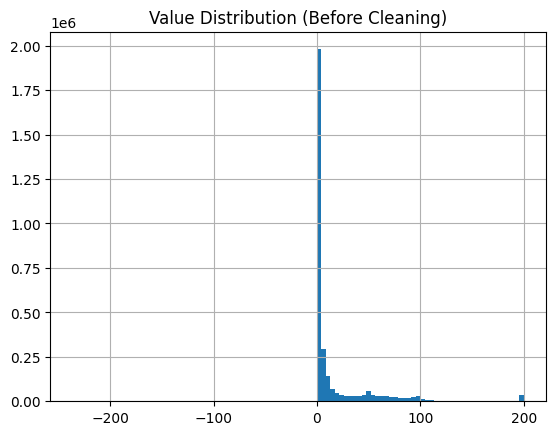

In [7]:
df['value'].clip(upper=200).hist(bins=100)
plt.title('Value Distribution (Before Cleaning)')

In [18]:
df['value'].value_counts()

value
1.000000      1601457
0.100000         8407
0.010000         2485
0.200000         2231
0.300000         2052
               ...   
55.868481           1
123.048531          1
49.922884           1
49.889299           1
8.047802            1
Name: count, Length: 1228024, dtype: int64

Berdasarkan visualisasi di atas, terdapat **penumpukan data yang sangat tinggi (1,6jt data) pada nilai sekitar 1**. Hal ini menyebabkan distribusi menjadi tidak seimbang dan mengindikasikan adanya nilai tidak valid yang mendominasi dataset. Maka dari itu, pola distribusi data sebenarnya tidak dapat diamati dengan jelas.

Text(0.5, 1.0, 'Value Distribution (After Cleaning)')

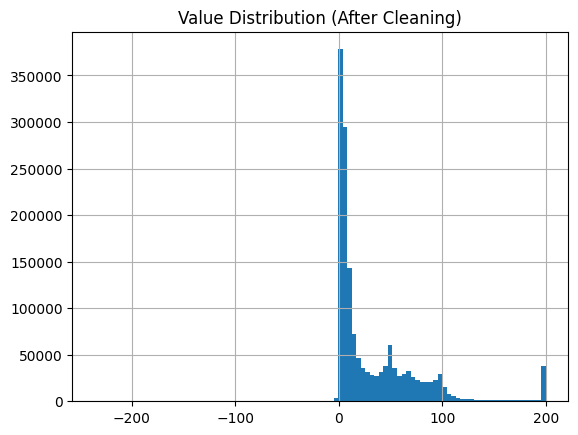

In [8]:
df_clean = df.copy()
df_clean['value'] = df_clean['value'].replace(1, np.nan)

df_clean['value'].clip(upper=200).hist(bins=100)
plt.title('Value Distribution (After Cleaning)')

Berdasarkan visualisasi di atas, dilakukan proses *cleaning* dengan menghapus nilai tidak valid, **distribusi data menjadi lebih representatif**. Pola distribusi yang sebelumnya tertutup kini terlihat lebih jelas, dengan mayoritas nilai berada pada rentang 0 hingga 100. Selain itu, masih terdapat outlier serta nilai negatif yang berasal dari indikator tertentu.

## **EDA PER INDIKATOR**

### **Life Expectancy (TARGET)**

In [20]:
life_expect = df_clean[df_clean['indicator_name'] == 'Life expectancy at birth, total (years)']['value']
life_expect.describe()

count    14357.000000
mean        64.012362
std         11.237110
min         18.907000
25%         56.034000
50%         66.867000
75%         72.489000
max         85.417073
Name: value, dtype: float64

Berdasarkan statistik deskriptif, distribusi harapan hidup menunjukkan bahwa sebagian besar negara berada pada rentang 60–75 tahun tetapi terdapat nilai ekstrem rendah hingga 19 tahun. Hal tersebut mengindikasikan adanya *outlier* atau kondisi ekstrem pada beberapa negara. Perbedaan antara `mean` (64.01) dan `median` (66.86) menunjukkan distribusi yang sedikit condong ke kiri akibat nilai rendah tersebut. *Variance* yang cukup tinggi (std = 11.23) mencerminkan ketimpangan antar negara.

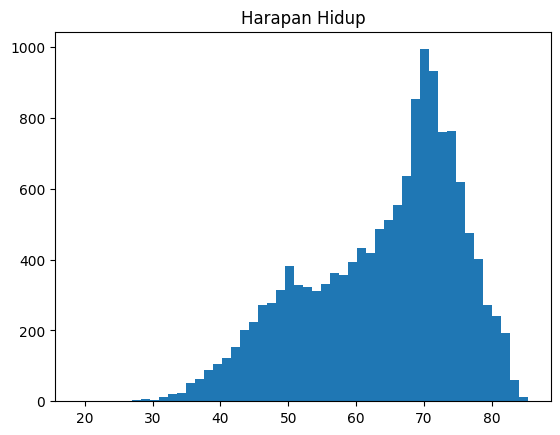

In [21]:
plt.hist(life_expect, bins=50)
plt.title('Harapan Hidup')
plt.show()

Berdasarkan visualisasi di atas, distribusi condong ke kanan (*right-skewed* ringan). Hal ini dapat diartikan bahwa mayoritas negara punya harapan hidup di range 65-75 dan negara dengan `life expectancy` rendah jumlahnya lebih sedikit.

### **Demografi**

In [22]:
growth = df_clean[df_clean['indicator_name'] == 'Population growth (annual %)']['value']
growth.describe()

count    15616.000000
mean         1.774975
std          1.575610
min        -10.955149
25%          0.753924
50%          1.725702
75%          2.636813
max         28.041032
Name: value, dtype: float64

Berdasarkan statistik deskriptif, distribusi pertumbuhan populasi global menunjukkan bahwa sebagian besar negara mengalami pertumbuhan stabil pada kisaran 0-3% per tahun. Nilai rata-rata (1.77%) dan median (1.73%) yang hampir identik mengindikasikan distribusi relatif seimbang di pusat. Walaupun itu, terdapat nilai ekstrem seperti -10.95% dan 28.04% yang menunjukkan adanya outlier. Kemungkinan disebabkan oleh anomali data seperti konflik atau perubahan administratif wilayah.

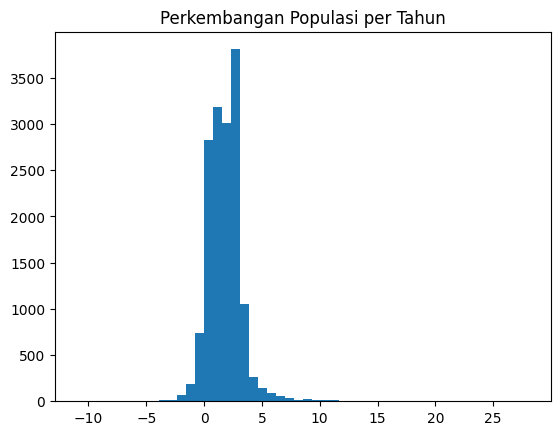

In [23]:
plt.hist(growth, bins=50)
plt.title('Perkembangan Populasi per Tahun')
plt.show()

Berdasarkan visualisasi di atas, distribusi condong ke kanan (*right-skewed*). Hal ini dapat diartikan bahwa mayoritas pertumbuhan di 0–3%. Kebanyakan negara tumbuh stabil tetapi ada beberapa kasus ekstrem.

In [24]:
df_demo = df[df['indicator_name'].isin([
    'Population ages 0-14 (% of total population)',
    'Urban population (% of total population)',
    'Population ages 65 and above (% of total population)',
    'Age dependency ratio (% of working-age population)'
])]

In [25]:
df_demo.groupby('indicator_name')['value'].describe()

,count,mean,std,min,25%,50%,75%,max
indicator_name,,,,,,,,
Age dependency ratio (% of working-age population),14476.0,71.372312,19.653951,1.000000,53.248344,71.379266,88.620879,121.051685
Population ages 0-14 (% of total population),14509.0,34.486370,10.285759,11.048402,25.389178,37.255855,43.667152,51.638824
Population ages 65 and above (% of total population),14509.0,6.364716,4.362798,0.685592,3.187611,4.453692,8.570065,28.397273
Urban population (% of total population),15790.0,46.980795,24.637315,1.000000,27.391000,46.160000,66.901000,99.980000


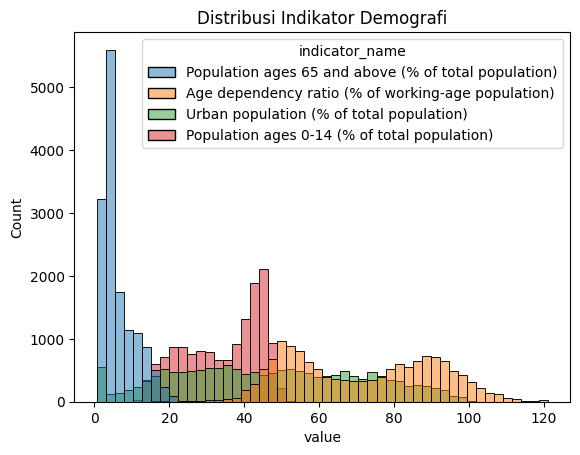

In [26]:
sns.histplot(data=df_demo, x='value', hue='indicator_name', bins=50, alpha=0.5)
plt.title('Distribusi Indikator Demografi')
plt.show()

Berdasarkan statistik deskriptif dan visualisasi di atas, distribusi indikator demografi menunjukkan bahwa sebagian besar negara masih didominasi oleh populasi usia muda dengan rata-rata usia 0–14 sebesar 34.48%. Sebaliknya, proporsi lansia relatif rendah dengan rata-rata 6.36%. Walaupun itu, terdapat beberapa negara dengan tingkat penuaan populasi yang tinggi hingga 28%. Rasio ketergantungan yang cukup tinggi dengan rata-rata sebesar 71.37 menunjukkan beban ekonomi yang signifikan terhadap kelompok usia produktif.

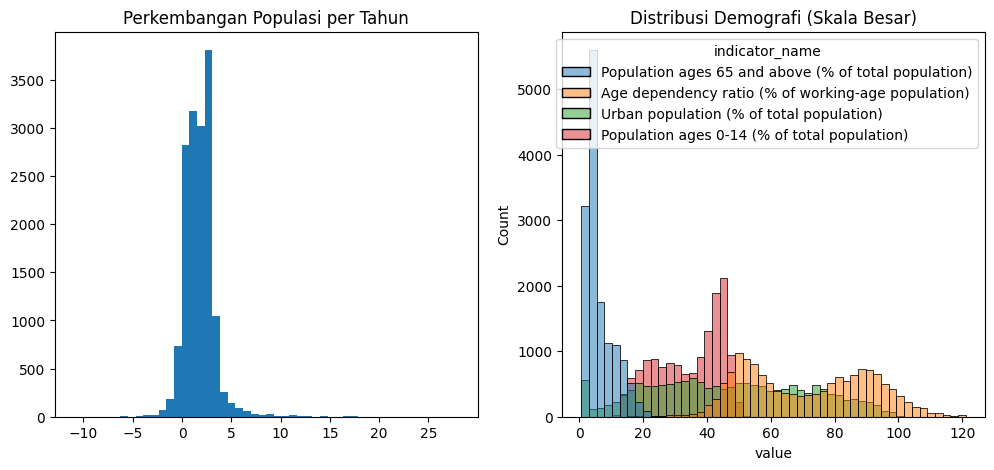

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# kiri (growth)
axes[0].hist(growth, bins=50)
axes[0].set_title('Perkembangan Populasi per Tahun')

# kanan (skala besar)
sns.histplot(data=df_demo, x='value', hue='indicator_name', bins=50, alpha=0.5, ax=axes[1])
axes[1].set_title('Distribusi Demografi (Skala Besar)')

plt.show()

### **Hasil Kesehatan**

In [28]:
df_mort = df_clean[df_clean['indicator_name'].isin([
    'Mortality rate, infant (per 1,000 live births)',
    'Mortality rate, under-5 (per 1,000)',
    'Death rate, crude (per 1,000 people)'
])]

In [29]:
df_mort.groupby('indicator_name')['value'].describe()

,count,mean,std,min,25%,50%,75%,max
indicator_name,,,,,,,,
"Death rate, crude (per 1,000 people)",14290.0,10.620919,5.292048,1.127,7.021000,9.299184,12.68675,54.444
"Mortality rate, infant (per 1,000 live births)",10727.0,49.949156,44.039354,1.500,14.900000,36.300000,73.15000,279.700
"Mortality rate, under-5 (per 1,000)",10782.0,74.426001,74.633120,1.700,17.704117,46.300000,108.50000,420.600


Berdasarkan statistik deskriptif, distribusi indikator kematian menunjukkan ketimpangan antar negara. Sementara tingkat kematian kasar relatif stabil, indikator kematian bayi dan anak di bawah lima tahun menunjukkan variasi yang sangat tinggi dengan distribusi yang condong ke kanan. Hal ini dapat diartikan bahwa kualitas layanan kesehatan memiliki pengaruh besar terhadap tingkat kematian anak. Oleh karena itu, kualitas layanan menjadikan indikator lebih sensitif dalam mengukur tingkat pembangunan suatu negara.

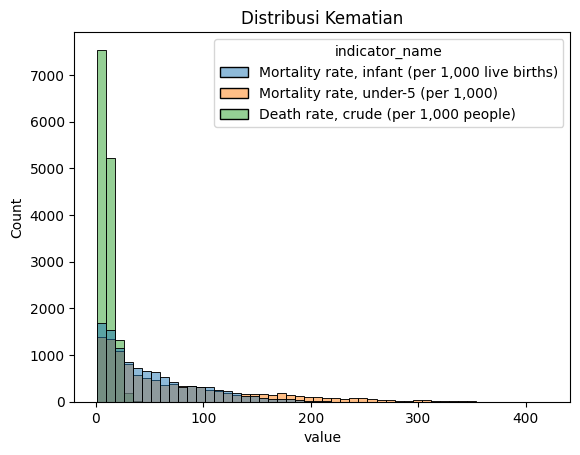

In [30]:
sns.histplot(data=df_mort, x='value', hue='indicator_name', bins=50, alpha=0.5)
plt.title('Distribusi Kematian')
plt.show()

Berdasarkan visualisasi di atas, semua distribusi condong ke kanan (*right-skewed*). Hal ini dapat diartikan bahwa mayoritas negara dengan kondisi relatif baik tapi ada sebagian negara dengan angka kematian sangat tinggi (*outlier*).

### **Sistem Kesehatan**

In [31]:
cur_health_exp = df_clean[df_clean['indicator_name'] == 'Current health expenditure per capita (current US$)']['value']
cur_health_exp.describe()

count     4376.000000
mean       859.311721
std       1531.233643
min          4.335375
25%         63.807074
50%        238.325120
75%        744.105438
max      10623.849609
Name: value, dtype: float64

Berdasarkan statistik deskriptif, distribusi pengeluaran kesehatan per kapita menunjukkan ketimpangan yang sangat tinggi. Sebagian besar negara memiliki pengeluaran yang relatif rendah, dengan median sebesar 238 USD, sementara rata-rata jauh lebih tinggi sebesar 859 USD. Hal tersebut dipengaruhi oleh sejumlah kecil negara dengan pengeluaran sangat besar hingga lebih dari 10000 USD. Distribusi yang sangat condong ke kanan ini mencerminkan kesenjangan signifikan dalam akses terhadap layanan kesehatan.

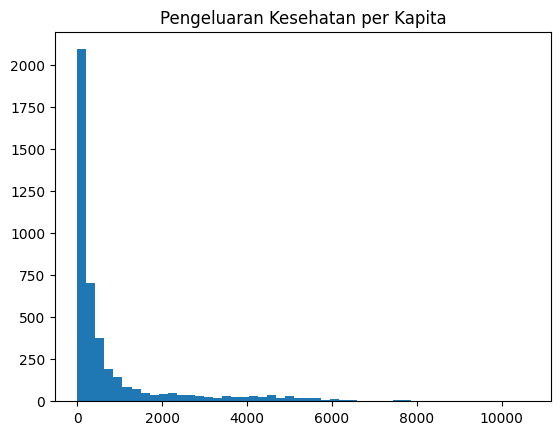

In [32]:
plt.hist(cur_health_exp, bins=50)
plt.title('Pengeluaran Kesehatan per Kapita')
plt.show()

Berdasarkan visualisasi di atas, semua distribusi condong ke kanan (*right-skewed*). Hal ini dapat diartikan bahwa mayoritas negara memiliki pengeluaran rendah, sementara negara sisanya memiliki pengeluaran sangat tinggi (*outlier*).

In [33]:
df_system = df_clean[df_clean['indicator_name'].isin([
    'Physicians (per 1,000 people)',
    'Nurses and midwives (per 1,000 people)',
    'Hospital beds (per 1,000 people)'
])]

In [34]:
df_system.groupby('indicator_name')['value'].describe()

,count,mean,std,min,25%,50%,75%,max
indicator_name,,,,,,,,
"Hospital beds (per 1,000 people)",4735.0,4.371531,3.363011,0.0100,1.7520,3.4000,6.2700,40.315456
"Nurses and midwives (per 1,000 people)",2717.0,4.949309,8.258266,0.0478,1.4000,3.8311,6.7002,185.314000
"Physicians (per 1,000 people)",4798.0,1.610347,1.355529,0.0008,0.3729,1.3471,2.5812,8.421800


Berdasarkan statistik deskriptif, distribusi indikator sistem kesehatan menunjukkan bahwa sebagian besar negara memiliki kapasitas layanan kesehatan yang terbatas, terutama jumlah tenaga medis. Variasi terbesar terlihat pada jumlah perawat dan bidan menunjukkan ketimpangan signifikan antar negara. Sementara itu, jumlah dokter relatif lebih stabil, walaupun masih menunjukkan keterbatasan di mayoritas negara. Hal ini menunjukkan bahwa ketersediaan tenaga kesehatan menjadi faktor penting dalam menentukan kualitas sistem kesehatan.

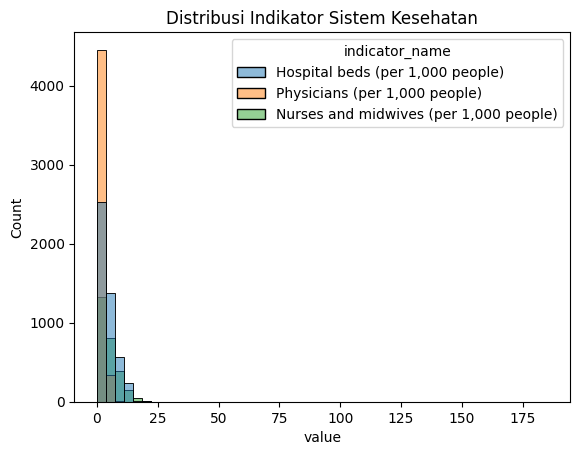

In [35]:
sns.histplot(data=df_system, x='value', hue='indicator_name', bins=50, alpha=0.5)
plt.title('Distribusi Indikator Sistem Kesehatan')
plt.show()

Berdasarkan visualisasi di atas, semua distribusi condong ke kanan (*right-skewed*). Hal ini dapat diartikan bahwa mayoritas negara memiliki kapasitas sistem kesehatan terbatas, di sisi lain sedikit negara memiliki sistem kesehatan sangat kuat

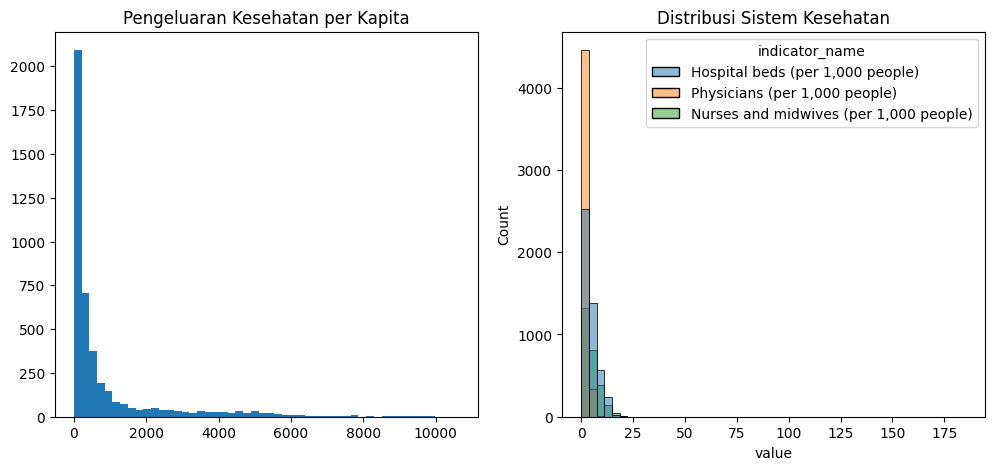

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# kiri (cur_health_exp)
axes[0].hist(cur_health_exp, bins=50)
axes[0].set_title('Pengeluaran Kesehatan per Kapita')

# kanan (skala besar)
sns.histplot(data=df_system, x='value', hue='indicator_name', bins=50, alpha=0.5, ax=axes[1])
axes[1].set_title('Distribusi Sistem Kesehatan')

plt.show()

### **Sanitasi**

In [37]:
df_san = df_clean[df_clean['indicator_name'].isin([
    'People using safely managed drinking water services (% of population)',
    'People using safely managed sanitation services (% of population)',
    'People with basic handwashing facilities including soap and water (% of population)'
])]

In [38]:
df_san.groupby('indicator_name')['value'].describe()

,count,mean,std,min,25%,50%,75%,max
indicator_name,,,,,,,,
People using safely managed drinking water services (% of population),2963.0,69.267835,29.935298,2.331173,46.776246,78.835151,95.959008,100.000003
People using safely managed sanitation services (% of population),3270.0,51.079232,28.232119,2.116907,24.891356,47.165268,78.195179,100.000004
People with basic handwashing facilities including soap and water (% of population),1389.0,49.689879,31.676978,0.667819,21.256326,46.363888,83.246008,99.849215


Berdasarkan statistik deskriptif, distribusi indikator sanitasi menunjukkan adanya kesenjangan. Akses terhadap air minum yang aman relatif lebih tinggi dibandingkan dengan sanitasi dan fasilitas cuci tangan. Hal ini menunjukkan bahwa tantangan utama terletak pada pengembangan infrastruktur sanitasi dan peningkatan praktik kebersihan. Variasi yang tinggi pada indikator sanitasi dan kebersihan menunjukkan bahwa faktor ini menjadi salah satu penentu utama dalam perbedaan tingkat kesehatan antar negara.

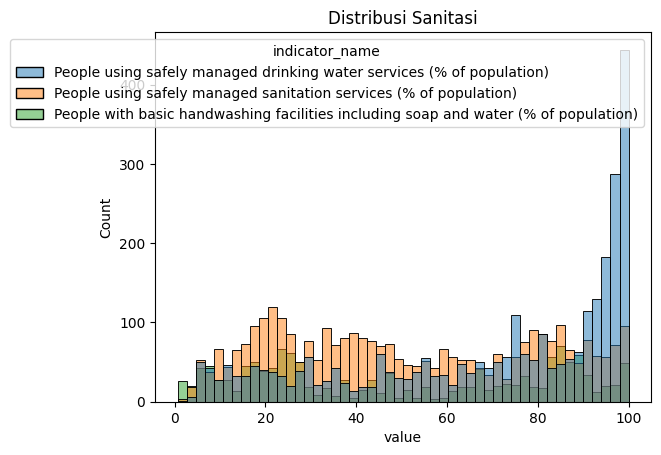

In [39]:
sns.histplot(data=df_san, x='value', hue='indicator_name', bins=50, alpha=0.5)
plt.title('Distribusi Sanitasi')
plt.show()

Berdasarkan visualisasi di atas, distribusi data cenderung menyebar luas. Hal ini dapat diartikan bahwa banyak negara dengan akses sanitasi bagus, banyak juga negara dengan akses sanitasi buruk.

### **Nutrisi**

In [40]:
df_nut = df_clean[df_clean['indicator_name'].isin([
    'Prevalence of undernourishment (% of population)',
    'Prevalence of stunting, height for age (% of children under 5)'
])]

In [41]:
df_nut.groupby('indicator_name')['value'].describe()

,count,mean,std,min,25%,50%,75%,max
indicator_name,,,,,,,,
"Prevalence of stunting, height for age (% of children under 5)",851.0,28.380141,16.011685,0.8,15.450000,28.1,39.750000,73.6
Prevalence of undernourishment (% of population),3688.0,11.161504,11.000687,2.5,2.507275,7.1,15.349208,81.7


Berdasarkan statistik deskriptif, distribusi indikator nutrisi menunjukkan bahwa meskipun sebagian besar negara memiliki tingkat kekurangan gizi yang relatif rendah, masih terdapat sejumlah negara dengan tingkat yang sangat tinggi. Prevalensi *stunting* pada anak menunjukkan distribusi yang lebih merata dan tinggi dibandingkan dengan *undernourishment* mengindikasikan bahwa masalah gizi kronis masih menjadi tantangan yang signifikan. Hal ini menunjukkan bahwa perbaikan akses makanan saja tidak cukup, tetapi juga diperlukan peningkatan kualitas gizi, sanitasi, dan layanan kesehatan untuk mengatasi masalah nutrisi.

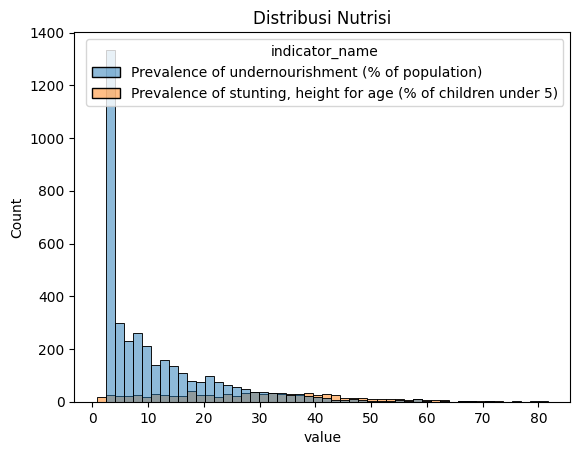

In [42]:
sns.histplot(data=df_nut, x='value', hue='indicator_name', bins=50, alpha=0.5)
plt.title('Distribusi Nutrisi')
plt.show()

Berdasarkan visualisasi di atas, semua distribusi condong ke kanan (*right-skewed*). Hal ini dapat diartikan bahwa mayoritas negara memiliki kapasitas yang cukup terkait nutrisi di sisi lain masih ada juga yang berat banget permasalahan ini.

### **Reproduksi**

In [43]:
fert_rate = df_clean[df_clean['indicator_name'] == 'Fertility rate, total (births per woman)']['value']
fert_rate.describe()

count    14353.000000
mean         3.983829
std          1.976245
min          0.860000
25%          2.140000
50%          3.582000
75%          5.843000
max          8.864000
Name: value, dtype: float64

In [44]:
adole_fert_rate = df_clean[df_clean['indicator_name'] == 'Adolescent fertility rate (births per 1,000 women ages 15-19)']['value']
adole_fert_rate.describe()

count    14264.000000
mean        76.067344
std         52.499750
min          0.283000
25%         31.974500
50%         65.477400
75%        111.677753
max        232.483800
Name: value, dtype: float64

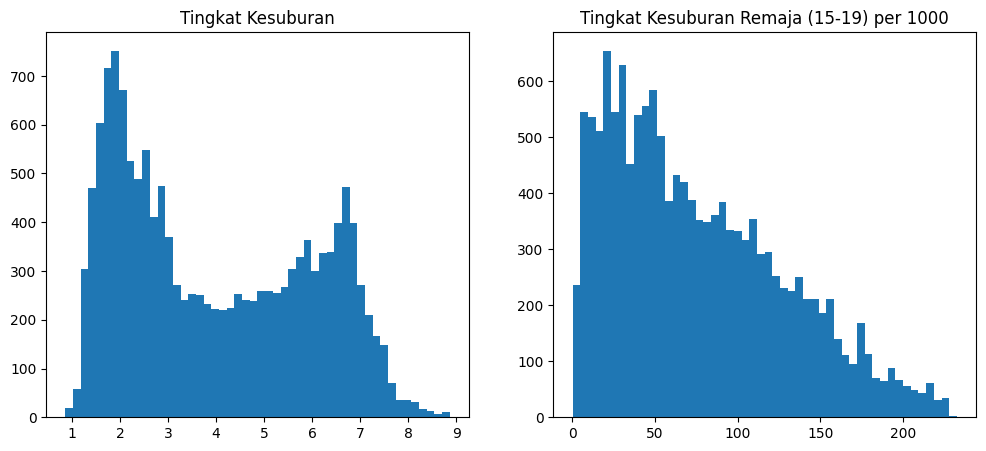

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].hist(fert_rate, bins=50)
axes[0].set_title('Tingkat Kesuburan')

axes[1].hist(adole_fert_rate, bins=50)
axes[1].set_title('Tingkat Kesuburan Remaja (15-19) per 1000')
plt.show()

Berdasarkan statistik deskriptif dan visualisasi di atas, distribusi tingkat kesuburan menunjukkan adanya perbedaan yang jelas antara negara maju dan berkembang. Fertility rate total menunjukkan pola tersebar, dengan satu kelompok negara memiliki tingkat kesuburan rendah dan kelompok lainnya memiliki tingkat kesuburan tinggi. Sementara itu, tingkat kesuburan remaja menunjukkan distribusi yang condong ke kanan (*right-skewed*) dengan variasi yang besar, mengindikasikan adanya kesenjangan dalam akses layanan kesehatan reproduksi. Tingginya tingkat kesuburan remaja menjadi indikator penting dari rendahnya tingkat pembangunan sosial dan ekonomi.

## **Harapan Hidup Berdasarkan Negara**

In [46]:
df_le = df_clean[df_clean['indicator_name'] == 'Life expectancy at birth, total (years)']

print('Top 5 Tingkat Harapan Hidup Tertinggi Berdasarkan Negara')
print(df_le.groupby('country_name')['value'].mean().sort_values(ascending=False).head())
print('\nTop 5 Tingkat Harapan Hidup Terendah Berdasarkan Negara')
print(df_le.groupby('country_name')['value'].mean().sort_values().head())

Top 5 Tingkat Harapan Hidup Tertinggi Berdasarkan Negara
country_name
San Marino        85.417073
Cayman Islands    82.190244
Liechtenstein     80.585084
Faroe Islands     78.769648
Bermuda           78.417526
Name: value, dtype: float64

Top 5 Tingkat Harapan Hidup Terendah Berdasarkan Negara
country_name
Sierra Leone    40.966317
Mali            43.879067
South Sudan     44.339050
Niger           45.495667
Nigeria         45.768700
Name: value, dtype: float64


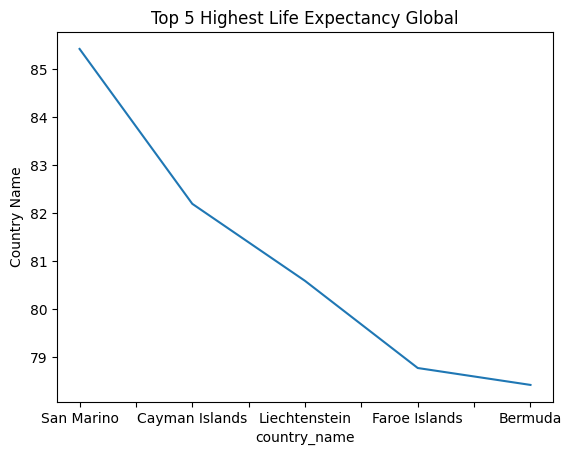

In [47]:
df_le.groupby('country_name')['value'].mean().sort_values(ascending=False).head().plot()
plt.title('Top 5 Highest Life Expectancy Global')
plt.ylabel('Country Name')
plt.show()

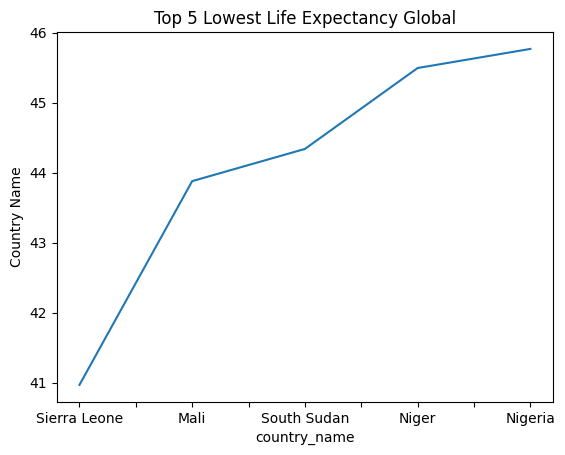

In [48]:
df_le.groupby('country_name')['value'].mean().sort_values().head().plot()
plt.title('Top 5 Lowest Life Expectancy Global')
plt.ylabel('Country Name')
plt.show()

Berdasarkan analisis **`country`**, negara dengan **tingkat harapan hidup tertinggi didominasi oleh negara kecil** dengan tingkat ekonomi tinggi dan sistem kesehatan yang baik, seperti San Marino dan Cayman Islands. Sementara itu, negara dengan **tingkat harapan hidup terendah umumnya berada di kawasan Sub-Saharan Africa**, yang menghadapi berbagai  tantangan seperti keterbatasan akses layanan kesehatan, tingkat kemiskinan tinggi, serta faktor lingkungan dan sosial lainnya.

## **Harapan Hidup Berdasarkan Wilayah**

In [49]:
df_le.groupby('region')['value'].mean().sort_values(ascending=False)

region
North America                 76.286702
Europe & Central Asia         72.161427
Latin America & Caribbean     68.366904
Middle East & North Africa    66.257733
East Asia & Pacific           65.922066
South Asia                    57.558546
Sub-Saharan Africa            51.585695
Name: value, dtype: float64

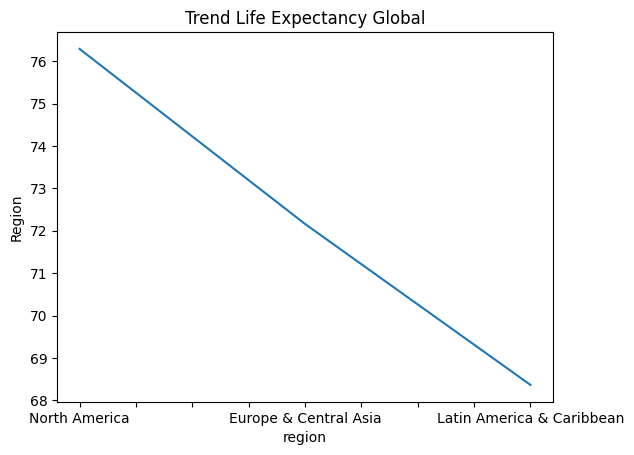

In [50]:
df_le.groupby('region')['value'].mean().sort_values(ascending=False).head(3).plot()
plt.title('Trend Life Expectancy Global')
plt.ylabel('Region')
plt.show()

Berdasarkan analisis **`region`**, terdapat perbedaan signifikan dalam tingkat harapan hidup antar wilayah. **North America dan Europe & Central Asia** menunjukkan nilai tertinggi, sedangkan **Sub-Saharan Africa** memiliki nilai terendah. Hal ini menunjukkan adanya kesenjangan kesehatan global yang kemungkinan dipengaruhi oleh faktor ekonomi, akses layanan kesehatan, dan kondisi sosial.

## **Harapan Hidup Berdasarkan Kelompok Penghasilan**

In [51]:
df_le.groupby('income_group')['value'].mean()

income_group
High income            73.575691
Low income             49.814521
Lower middle income    58.540134
Upper middle income    66.555230
Name: value, dtype: float64

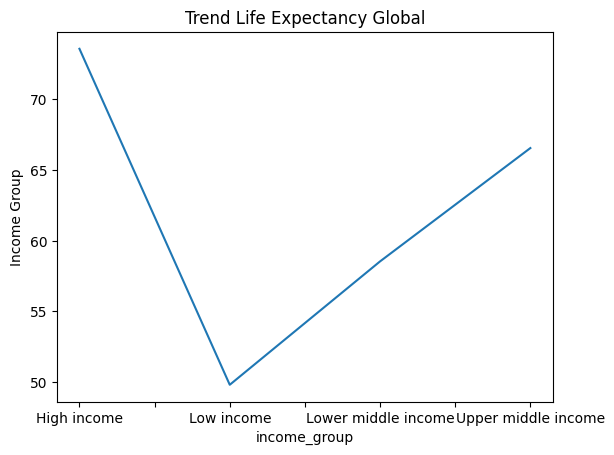

In [52]:
df_le.groupby('income_group')['value'].mean().plot()
plt.title('Trend Life Expectancy Global')
plt.ylabel('Income Group')
plt.show()

Berdasarkan analisis **`income_group`**, terdapat hubungan yang sangat kuat antara tingkat ekonomi dan kesehatan. Negara dengan pendapatan tinggi memiliki harapan hidup yang jauh lebih tinggi dibandingkan negara dengan pendapatan rendah. Hal tersebut mengindikasikan bahwa faktor ekonomi memainkan peran penting dalam menentukan kualitas kesehatan suatu negara.

## **Harapan Hidup Berdasarkan Tahun**

In [53]:
df_le.groupby('year')['value'].mean().sort_values(ascending=False)

year
2019    72.723370
2018    72.517118
2017    72.322737
2016    72.107209
2015    71.826736
          ...    
1964    55.229163
1963    54.795290
1962    54.373526
1961    53.985241
1960    53.434488
Name: value, Length: 61, dtype: float64

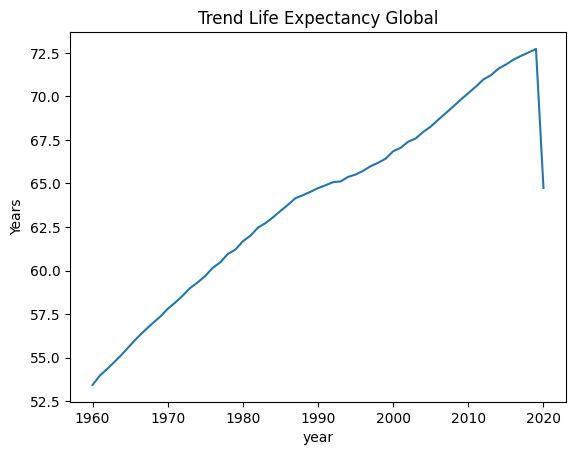

In [54]:
df_le.groupby('year')['value'].mean().plot()
plt.title('Trend Life Expectancy Global')
plt.ylabel('Years')
plt.show()

Berdasarkan analisis **`year`**, tingkat harapan hidup global mengalami **peningkatan yang konsisten dari tahun ke tahun**. Pada tahun 1960, rata-rata harapan hidup berada di sekitar 53 tahun, dan meningkat menjadi 72 tahun pada tahun 2019. Terdapat penurunan pada tahun 2020 karena adanya virus covid. Peningkatan ini mencerminkan kemajuan signifikan dalam bidang kesehatan, seperti peningkatan akses terhadap layanan kesehatan, perbaikan sanitasi, dan perkembangan teknologi medis.

# **BAB 5. Feature Engineering**

Langkah selanjutnya adalah **`Feature Engineering`**. Langkah ini mengubah data mentah menjadi dataset yang bersih, terstruktur, dan siap digunakan untuk proses *model training*. Proses ini mencakup transformasi data, penanganan *missing values*, penyesuaian distribusi data, *scaling* fitur numerikal, dan *encoding* fitur kategorikal.

## **Turn Indicator into Feature**

Tahap ini melakukan transformasi data dari bentuk *long format* menjadi *wide* menggunakan *pivot table* agar setiap observasi memiliki seluruh fitur dalam satu baris sehingga dapat digunakan sebagai input model machine learning.

In [55]:
selected_indicators = [
    'Population growth (annual %)',
    'Urban population (% of total population)',
    'Population ages 0-14 (% of total population)',
    'Population ages 65 and above (% of total population)',
    'Age dependency ratio (% of working-age population)',

    'Mortality rate, infant (per 1,000 live births)',
    'Mortality rate, under-5 (per 1,000)',
    'Death rate, crude (per 1,000 people)',

    'Physicians (per 1,000 people)',
    'Nurses and midwives (per 1,000 people)',
    'Hospital beds (per 1,000 people)',
    'Current health expenditure per capita (current US$)',

    'People using safely managed drinking water services (% of population)',
    'People using safely managed sanitation services (% of population)',
    'People with basic handwashing facilities including soap and water (% of population)',

    'Prevalence of undernourishment (% of population)',
    'Prevalence of stunting, height for age (% of children under 5)',

    'Fertility rate, total (births per woman)',
    'Adolescent fertility rate (births per 1,000 women ages 15-19)',

    # target
    'Life expectancy at birth, total (years)'
]

In [56]:
''' 
    Membuat dataframe baru dengan memecah indicator_name menjadi sebuah fitur untuk mendeteksi
    life expectancy
'''
df_model = df_clean[df_clean['indicator_name'].isin(selected_indicators)]

df_health_population = df_model.pivot_table(
    index=['country_name', 'year', 'region', 'income_group'],
    columns='indicator_name',
    values='value'
).reset_index()
df_health_population

indicator_name,country_name,year,region,income_group,"Adolescent fertility rate (births per 1,000 women ages 15-19)",Age dependency ratio (% of working-age population),Current health expenditure per capita (current US$),"Death rate, crude (per 1,000 people)","Fertility rate, total (births per woman)","Hospital beds (per 1,000 people)",...,People using safely managed drinking water services (% of population),People using safely managed sanitation services (% of population),People with basic handwashing facilities including soap and water (% of population),"Physicians (per 1,000 people)",Population ages 0-14 (% of total population),Population ages 65 and above (% of total population),Population growth (annual %),"Prevalence of stunting, height for age (% of children under 5)",Prevalence of undernourishment (% of population),Urban population (% of total population)
0,Afghanistan,1960,South Asia,Low income,145.2450,81.617266,NaN,32.219,7.450,0.170627,...,NaN,NaN,NaN,0.0350,42.140851,2.798308,NaN,NaN,NaN,8.401
1,Afghanistan,1961,South Asia,Low income,145.2450,82.688678,NaN,31.649,7.450,NaN,...,NaN,NaN,NaN,NaN,42.453942,2.808131,1.898499,NaN,NaN,8.684
2,Afghanistan,1962,South Asia,Low income,145.2450,83.289370,NaN,31.093,7.450,NaN,...,NaN,NaN,NaN,NaN,42.637354,2.804113,1.965805,NaN,NaN,8.976
3,Afghanistan,1963,South Asia,Low income,145.2450,83.604075,NaN,30.551,7.450,NaN,...,NaN,NaN,NaN,NaN,42.748804,2.786171,2.029830,NaN,NaN,9.276
4,Afghanistan,1964,South Asia,Low income,145.2450,83.853840,NaN,30.022,7.450,NaN,...,NaN,NaN,NaN,NaN,42.854745,2.754223,2.090208,NaN,NaN,9.586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13163,Zimbabwe,2016,Sub-Saharan Africa,Lower middle income,90.6766,83.576729,113.408859,8.286,3.804,NaN,...,30.183683,26.877909,42.436694,0.1788,42.665088,2.861779,1.549294,NaN,NaN,32.296
13164,Zimbabwe,2017,Sub-Saharan Africa,Lower middle income,86.1350,83.466245,112.741936,8.044,3.707,NaN,...,29.997683,26.576824,42.425130,0.1859,42.597868,2.896191,1.459406,NaN,NaN,32.237
13165,Zimbabwe,2018,Sub-Saharan Africa,Lower middle income,83.2486,82.951113,140.320312,7.883,3.615,NaN,...,29.827913,26.272073,42.419642,0.2096,42.401066,2.939524,1.410382,NaN,NaN,32.209
13166,Zimbabwe,2019,Sub-Saharan Africa,Lower middle income,80.3622,82.277964,NaN,7.773,3.531,NaN,...,29.673569,25.963544,42.419840,NaN,42.158127,2.980608,1.421142,23.5,NaN,32.210


Berdasarkan output di atas, terdapat dataframe baru yaitu df_health_population dengan memecah beberapa `indicator_name` menjadi sebuah fitur baru berisikan values.

In [57]:
''' 
    Mengubah nama kolom agar lebih mudah diolah.
'''
df_health_population.columns = df_health_population.columns.str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '').str.replace(',', '').str.replace('%', 'pct')

In [58]:
df_health_population.columns

Index(['country_name', 'year', 'region', 'income_group',
       'adolescent_fertility_rate_births_per_1000_women_ages_15-19',
       'age_dependency_ratio_pct_of_working-age_population',
       'current_health_expenditure_per_capita_current_us$',
       'death_rate_crude_per_1000_people',
       'fertility_rate_total_births_per_woman',
       'hospital_beds_per_1000_people', 'life_expectancy_at_birth_total_years',
       'mortality_rate_infant_per_1000_live_births',
       'mortality_rate_under-5_per_1000',
       'nurses_and_midwives_per_1000_people',
       'people_using_safely_managed_drinking_water_services_pct_of_population',
       'people_using_safely_managed_sanitation_services_pct_of_population',
       'people_with_basic_handwashing_facilities_including_soap_and_water_pct_of_population',
       'physicians_per_1000_people',
       'population_ages_0-14_pct_of_total_population',
       'population_ages_65_and_above_pct_of_total_population',
       'population_growth_annual_pct

In [59]:
''' 
    Membuat fitur baru untuk mengelompokkan life_expectancy_at_birth_total_years.
    Jika values lebih dari median maka akan dilabel sebagai 1 dan sebaliknya akan dilabel sebagai 0.
'''
df_health_population['health_status'] = df_health_population['life_expectancy_at_birth_total_years'].apply(
    lambda x: 1 if x >= df_health_population['life_expectancy_at_birth_total_years'].median() else 0
)

In [60]:
df_health_population

indicator_name,country_name,year,region,income_group,adolescent_fertility_rate_births_per_1000_women_ages_15-19,age_dependency_ratio_pct_of_working-age_population,current_health_expenditure_per_capita_current_us$,death_rate_crude_per_1000_people,fertility_rate_total_births_per_woman,hospital_beds_per_1000_people,...,people_using_safely_managed_sanitation_services_pct_of_population,people_with_basic_handwashing_facilities_including_soap_and_water_pct_of_population,physicians_per_1000_people,population_ages_0-14_pct_of_total_population,population_ages_65_and_above_pct_of_total_population,population_growth_annual_pct,prevalence_of_stunting_height_for_age_pct_of_children_under_5,prevalence_of_undernourishment_pct_of_population,urban_population_pct_of_total_population,health_status
0,Afghanistan,1960,South Asia,Low income,145.2450,81.617266,NaN,32.219,7.450,0.170627,...,NaN,NaN,0.0350,42.140851,2.798308,NaN,NaN,NaN,8.401,0
1,Afghanistan,1961,South Asia,Low income,145.2450,82.688678,NaN,31.649,7.450,NaN,...,NaN,NaN,NaN,42.453942,2.808131,1.898499,NaN,NaN,8.684,0
2,Afghanistan,1962,South Asia,Low income,145.2450,83.289370,NaN,31.093,7.450,NaN,...,NaN,NaN,NaN,42.637354,2.804113,1.965805,NaN,NaN,8.976,0
3,Afghanistan,1963,South Asia,Low income,145.2450,83.604075,NaN,30.551,7.450,NaN,...,NaN,NaN,NaN,42.748804,2.786171,2.029830,NaN,NaN,9.276,0
4,Afghanistan,1964,South Asia,Low income,145.2450,83.853840,NaN,30.022,7.450,NaN,...,NaN,NaN,NaN,42.854745,2.754223,2.090208,NaN,NaN,9.586,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13163,Zimbabwe,2016,Sub-Saharan Africa,Lower middle income,90.6766,83.576729,113.408859,8.286,3.804,NaN,...,26.877909,42.436694,0.1788,42.665088,2.861779,1.549294,NaN,NaN,32.296,0
13164,Zimbabwe,2017,Sub-Saharan Africa,Lower middle income,86.1350,83.466245,112.741936,8.044,3.707,NaN,...,26.576824,42.425130,0.1859,42.597868,2.896191,1.459406,NaN,NaN,32.237,0
13165,Zimbabwe,2018,Sub-Saharan Africa,Lower middle income,83.2486,82.951113,140.320312,7.883,3.615,NaN,...,26.272073,42.419642,0.2096,42.401066,2.939524,1.410382,NaN,NaN,32.209,0
13166,Zimbabwe,2019,Sub-Saharan Africa,Lower middle income,80.3622,82.277964,NaN,7.773,3.531,NaN,...,25.963544,42.419840,NaN,42.158127,2.980608,1.421142,23.5,NaN,32.210,0


Berdasarkan output di atas, saya membagi `health_status` menjadi 2, yaitu 0 sebagai indikasi status kesehatan suatu negara rendah dan 1 sebagai indikasi status kesehatan suatu negara tinggi. Thresholdnya adalah median dari `life_expectancy_at_birth_total_years`. Nantinya fitur ini akan digunakan sebagai target.

In [61]:
df_health_population['health_status'].value_counts()

health_status
0    7341
1    5827
Name: count, dtype: int64

Berdasarkan output di atas, terdapat 7341 dengan status kesehatan rendah dan 5827 dengan status kesehatan tinggi di fitur `health_status.

## **Split between X dan y**

Tahap ini memisahkan **feature (X) dengan target (y)**. *Feature* merupakan semua kolom kecuali `health_status` sebagai *threshold* life expectancy dan `Life expectancy at birth, total (years)`, sementara target merupakan `health_status`.

In [62]:
'''
    Memisah independent variables dengan target yang mau
    diprediksi. X dijadikan sebagai input dan y dijadikan
    sebagai output.
'''

X = df_health_population.drop(columns=['health_status', 'life_expectancy_at_birth_total_years'], axis=1)
y = df_health_population['health_status']

print(X)
print(y)

indicator_name country_name  year              region         income_group  \
0               Afghanistan  1960          South Asia           Low income   
1               Afghanistan  1961          South Asia           Low income   
2               Afghanistan  1962          South Asia           Low income   
3               Afghanistan  1963          South Asia           Low income   
4               Afghanistan  1964          South Asia           Low income   
...                     ...   ...                 ...                  ...   
13163              Zimbabwe  2016  Sub-Saharan Africa  Lower middle income   
13164              Zimbabwe  2017  Sub-Saharan Africa  Lower middle income   
13165              Zimbabwe  2018  Sub-Saharan Africa  Lower middle income   
13166              Zimbabwe  2019  Sub-Saharan Africa  Lower middle income   
13167              Zimbabwe  2020  Sub-Saharan Africa  Lower middle income   

indicator_name  adolescent_fertility_rate_births_per_1000_women

In [63]:
X.isnull().sum()

indicator_name
country_name                                                                               0
year                                                                                       0
region                                                                                     0
income_group                                                                               0
adolescent_fertility_rate_births_per_1000_women_ages_15-19                              1604
age_dependency_ratio_pct_of_working-age_population                                      1438
current_health_expenditure_per_capita_current_us$                                       9647
death_rate_crude_per_1000_people                                                        1581
fertility_rate_total_births_per_woman                                                   1518
hospital_beds_per_1000_people                                                           9417
mortality_rate_infant_per_1000_live_births             

## **Split numerical columns and categorical columns**

Tahap ini **mengelompokkan fitur berdasarkan tipe data**. Dibagi menjadi dua yaitu `num_cols` dan `cat_cols`. `num_cols` berisikan fitur numerik yang membutuhkan proses *scaling*, sementara `cat_cols` berisikan fitur kategorikan yang membutuhkan proses *encoding*.

In [64]:
'''
    Memeriksa kolom apa saja yang ada di X.
'''

X.columns

Index(['country_name', 'year', 'region', 'income_group',
       'adolescent_fertility_rate_births_per_1000_women_ages_15-19',
       'age_dependency_ratio_pct_of_working-age_population',
       'current_health_expenditure_per_capita_current_us$',
       'death_rate_crude_per_1000_people',
       'fertility_rate_total_births_per_woman',
       'hospital_beds_per_1000_people',
       'mortality_rate_infant_per_1000_live_births',
       'mortality_rate_under-5_per_1000',
       'nurses_and_midwives_per_1000_people',
       'people_using_safely_managed_drinking_water_services_pct_of_population',
       'people_using_safely_managed_sanitation_services_pct_of_population',
       'people_with_basic_handwashing_facilities_including_soap_and_water_pct_of_population',
       'physicians_per_1000_people',
       'population_ages_0-14_pct_of_total_population',
       'population_ages_65_and_above_pct_of_total_population',
       'population_growth_annual_pct',
       'prevalence_of_stunting_height

In [65]:
'''
    Memisahkan kolom menjadi 2 kategori, yaitu num_cols yang berisi
    kategori angka dan cat_cols yang berisi kategori string.
'''

num_cols = [
    'year', 'adolescent_fertility_rate_births_per_1000_women_ages_15-19',
    'age_dependency_ratio_pct_of_working-age_population',
    'current_health_expenditure_per_capita_current_us$',
    'death_rate_crude_per_1000_people', 'fertility_rate_total_births_per_woman',
    'hospital_beds_per_1000_people', 'mortality_rate_infant_per_1000_live_births',
    'mortality_rate_under-5_per_1000', 'nurses_and_midwives_per_1000_people',
    'people_using_safely_managed_drinking_water_services_pct_of_population',
    'people_using_safely_managed_sanitation_services_pct_of_population',
    'people_with_basic_handwashing_facilities_including_soap_and_water_pct_of_population',
    'physicians_per_1000_people', 'population_ages_0-14_pct_of_total_population',
    'population_ages_65_and_above_pct_of_total_population',
    'population_growth_annual_pct', 
    'prevalence_of_stunting_height_for_age_pct_of_children_under_5',
    'prevalence_of_undernourishment_pct_of_population',
    'urban_population_pct_of_total_population'
]

cat_cols = [
    'country_name', 'region', 'income_group'
]

## **Cardinality Check for Categorical Columns**

In [66]:
'''
    Melakukan perulangan di dalam kolom kategori.
'''

for i in cat_cols:
    print(f'Jumlah unique value dari kolom {i} : {X[i].nunique()}') # menghitung data yg unik dari kolom kategori
    print(f'Unique value dari kolom {i} : {X[i].unique()}') # menampilkan data kategori yang unik
    print('')

Jumlah unique value dari kolom country_name : 216
Unique value dari kolom country_name : ['Afghanistan' 'Albania' 'Algeria' 'American Samoa' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas, The' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'British Virgin Islands'
 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cabo Verde'
 'Cambodia' 'Cameroon' 'Canada' 'Cayman Islands'
 'Central African Republic' 'Chad' 'Channel Islands' 'Chile' 'China'
 'Colombia' 'Comoros' 'Congo, Dem. Rep.' 'Congo, Rep.' 'Costa Rica'
 "Cote d'Ivoire" 'Croatia' 'Cuba' 'Curacao' 'Cyprus' 'Czech Republic'
 'Denmark' 'Djibouti' 'Dominica' 'Dominican Republic' 'Ecuador'
 'Egypt, Arab Rep.' 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Estonia'
 'Eswatini' 'Ethiopia' 'Faroe Islands' 'Fiji' 'Finland' 'France'
 'French Polynesia' 'Gabon' 'Gambia

Berdasarkan informasi di atas,
- `country_name` memiliki 216 kategori sehingga masuk ke **high cardinality**.
- `region` dan `income_group` memiliki jumlah kategori yang rendah ke sedang sehingga masuk ke **low to medium cardinality**.

Dapat disimpulkan bahwa `country_name` dan `year` perlu dihandle, sementara yang lain dapat lanjut ke proses *encoding*.

## **Splitting Dataset (train-set, test-set)**

Tahap ini **membagi data menjadi *train set* dan *test set***. Pembagian datanya adalah 80% untuk *training* (10534 data) dan 20% untuk *testing* (2634 data).

In [67]:
'''
    Data dibagi menjadi:
    - Train (80%) untuk training model.
    - Test (20%) untuk evaluasi.
    dengan parameter:
        - test_size=0.2 artinya 20% data jadi test.
        - random_state=12 artinya mengacak data selama 12 kali
        agar hasilnya konsisten.
'''

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('Train Size:', X_train.shape)
print('Test Size:', X_test.shape)

Train Size: (10534, 23)
Test Size: (2634, 23)


## **Split Numerical Columns and Categorical Columns for Train & Test**

In [68]:
'''
    Memisahkan fitur numerikal dan kategorikal pada masing-masing
    X_train2 dan X_test2.
'''

X_train_num = X_train[num_cols]
X_train_cat = X_train[cat_cols]

X_test_num = X_test[num_cols]
X_test_cat = X_test[cat_cols]

## **Handle Missing Value**

Tahap ini **memeriksa apakah ada *missing value* pada data**.

In [69]:
'''
    Mengecek missing value di X_train.
'''

X_train.isnull().sum()

indicator_name
country_name                                                                              0
year                                                                                      0
region                                                                                    0
income_group                                                                              0
adolescent_fertility_rate_births_per_1000_women_ages_15-19                             1302
age_dependency_ratio_pct_of_working-age_population                                     1182
current_health_expenditure_per_capita_current_us$                                      7731
death_rate_crude_per_1000_people                                                       1271
fertility_rate_total_births_per_woman                                                  1222
hospital_beds_per_1000_people                                                          7531
mortality_rate_infant_per_1000_live_births                       

In [70]:
'''
    Mengecek missing value di X_test.
'''

X_test.isnull().sum()

indicator_name
country_name                                                                              0
year                                                                                      0
region                                                                                    0
income_group                                                                              0
adolescent_fertility_rate_births_per_1000_women_ages_15-19                              302
age_dependency_ratio_pct_of_working-age_population                                      256
current_health_expenditure_per_capita_current_us$                                      1916
death_rate_crude_per_1000_people                                                        310
fertility_rate_total_births_per_woman                                                   296
hospital_beds_per_1000_people                                                          1886
mortality_rate_infant_per_1000_live_births                       

In [71]:
'''
    Mengecek missing value di y_train.
'''

y_train.isnull().sum()

0

In [72]:
'''
    Mengecek missing value di y_test.
'''

y_test.isnull().sum()

0

Berdasarkan beberapa code di atas, sebagian besar kolom memiliki *missing values*, yaitu: 
- `adolescent_fertility_rate_births_per_1000_women_ages_15-19`
- `age_dependency_ratio_pct_of_working-age_population`
- `current_health_expenditure_per_capita_current_us$` 
- `death_rate_crude_per_1000_people`
- `fertility_rate_total_births_per_woman` 
- `hospital_beds_per_1000_people`
- `mortality_rate_infant_per_1000_live_births` 
- `mortality_rate_under-5_per_1000`
- `nurses_and_midwives_per_1000_people`
- `people_using_safely_managed_drinking_water_services_pct_of_population` 
- `people_using_safely_managed_sanitation_services_pct_of_population` 
- `people_with_basic_handwashing_facilities_including_soap_and_water_pct_of_population`
- `physicians_per_1000_people`
- `population_ages_0-14_pct_of_total_population`
- `population_ages_65_and_above_pct_of_total_population`
- `population_growth_annual_pct`
- `prevalence_of_stunting_height_for_age_pct_of_children_under_5`
- `prevalence_of_undernourishment_pct_of_population`
- `urban_population_pct_of_total_population`. 

Kolom dengan *missing values* yang lebih dari threshold (50%), akan saya *drop* kolomnya karena akan menimbulkan bias jika saya paksa imputasi. Kolom lainnya akan saya kaji ulang.

In [73]:
threshold = len(X_train) * 0.5
X_train = X_train.dropna(axis=1, thresh=threshold)

In [74]:
X_train.isnull().sum()

indicator_name
country_name                                                     0
year                                                             0
region                                                           0
income_group                                                     0
adolescent_fertility_rate_births_per_1000_women_ages_15-19    1302
age_dependency_ratio_pct_of_working-age_population            1182
death_rate_crude_per_1000_people                              1271
fertility_rate_total_births_per_woman                         1222
mortality_rate_infant_per_1000_live_births                    3045
mortality_rate_under-5_per_1000                               3051
population_ages_0-14_pct_of_total_population                  1152
population_ages_65_and_above_pct_of_total_population          1152
population_growth_annual_pct                                   212
urban_population_pct_of_total_population                       526
dtype: int64

In [75]:
threshold = len(X_test) * 0.5
X_test = X_test.dropna(axis=1, thresh=threshold)

In [76]:
X_test.isnull().sum()

indicator_name
country_name                                                    0
year                                                            0
region                                                          0
income_group                                                    0
adolescent_fertility_rate_births_per_1000_women_ages_15-19    302
age_dependency_ratio_pct_of_working-age_population            256
death_rate_crude_per_1000_people                              310
fertility_rate_total_births_per_woman                         296
mortality_rate_infant_per_1000_live_births                    778
mortality_rate_under-5_per_1000                               730
population_ages_0-14_pct_of_total_population                  252
population_ages_65_and_above_pct_of_total_population          252
population_growth_annual_pct                                   41
urban_population_pct_of_total_population                      129
dtype: int64

Semua kolom dengan *missing values* lebih dari *threshold* sudah didrop. Kemudian saya akan kaji ulang mengenai missing values yang belum dihandle. 

Menurut saya, *missing values* pada kolomlainnya terjadi karena adanya perbedaan kemampuan pelaporan data antar negara, terutama antara negara maju dan berkembang. Selain itu, beberapa indikator kesehatan tidak dikumpulkan setiap tahun karena bergantung pada survei yang memerlukan biaya besar. Akibatnya banyak indikator memiliki tingkat missing value yang cukup tinggi.

Karena missing values dapat dijelaskan bergantung pada kondisi yang berkaitan langsung dengan data tersebut (tingkat pembangunan atau sistem kesehatan), maka dikategorikan sebagai **Missing Not At Random (MNAR)**. Oleh karena itu, cara untuk menghandle missing value adalah dengan imputasi menggunakan median. 

In [77]:
'''
    Menggunakan imputer median untuk mengisi missing values di
    X_train dan X_test.
'''

median_imputer = SimpleImputer(strategy='median')

X_train[[
    'adolescent_fertility_rate_births_per_1000_women_ages_15-19', 'age_dependency_ratio_pct_of_working-age_population',
    'death_rate_crude_per_1000_people', 'fertility_rate_total_births_per_woman', 'mortality_rate_infant_per_1000_live_births', 
    'mortality_rate_under-5_per_1000', 'population_ages_0-14_pct_of_total_population', 'population_ages_65_and_above_pct_of_total_population', 
    'population_growth_annual_pct', 'urban_population_pct_of_total_population'
]] = median_imputer.fit_transform(X_train[[
    'adolescent_fertility_rate_births_per_1000_women_ages_15-19', 'age_dependency_ratio_pct_of_working-age_population',
    'death_rate_crude_per_1000_people', 'fertility_rate_total_births_per_woman', 'mortality_rate_infant_per_1000_live_births', 
    'mortality_rate_under-5_per_1000', 'population_ages_0-14_pct_of_total_population', 'population_ages_65_and_above_pct_of_total_population', 
    'population_growth_annual_pct', 'urban_population_pct_of_total_population'
]])

X_test[[
    'adolescent_fertility_rate_births_per_1000_women_ages_15-19', 'age_dependency_ratio_pct_of_working-age_population',
    'death_rate_crude_per_1000_people', 'fertility_rate_total_births_per_woman', 'mortality_rate_infant_per_1000_live_births', 
    'mortality_rate_under-5_per_1000', 'population_ages_0-14_pct_of_total_population', 'population_ages_65_and_above_pct_of_total_population', 
    'population_growth_annual_pct', 'urban_population_pct_of_total_population'
]] = median_imputer.transform(X_test[[
    'adolescent_fertility_rate_births_per_1000_women_ages_15-19', 'age_dependency_ratio_pct_of_working-age_population',
    'death_rate_crude_per_1000_people', 'fertility_rate_total_births_per_woman', 'mortality_rate_infant_per_1000_live_births', 
    'mortality_rate_under-5_per_1000', 'population_ages_0-14_pct_of_total_population', 'population_ages_65_and_above_pct_of_total_population', 
    'population_growth_annual_pct', 'urban_population_pct_of_total_population'
]])

In [78]:
'''
    Mengecek apakah masih ada missing values di X_train dan X_test.
'''

print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


Setelah imputasi median dilakukan, *train set* dan *test set* sudah tidak memiliki *missing values*.

## **Handle Outliers**

Tahap ini **melakukan analisis distribusi data untuk mengidentifikasi fitur yang memiliki *skewness* tinggi sehingga berpotensi mengandung *outlier***. Outlier banyak akan dihandle menggunakan IQR agar distribusi data lebih stabil menuju normal.

In [79]:
'''
    Membuat function untuk menghitung skewness dari kolom year, 'adolescent_fertility_rate_births_per_1000_women_ages_15-19', 
    'age_dependency_ratio_pct_of_working-age_population', 'death_rate_crude_per_1000_people', 'fertility_rate_total_births_per_woman', 
    'mortality_rate_infant_per_1000_live_births', 'mortality_rate_under-5_per_1000', 'population_ages_0-14_pct_of_total_population', 
    'population_ages_65_and_above_pct_of_total_population', 'population_growth_annual_pct', dan 'urban_population_pct_of_total_population'.
'''

def check_skewness(df2, *column_names):
    return {col: df2[col].skew() for col in column_names if col in df2.columns}

skewness_results = check_skewness(
    X_train,
    'year', 'adolescent_fertility_rate_births_per_1000_women_ages_15-19', 'age_dependency_ratio_pct_of_working-age_population',
    'death_rate_crude_per_1000_people', 'fertility_rate_total_births_per_woman', 'mortality_rate_infant_per_1000_live_births', 
    'mortality_rate_under-5_per_1000', 'population_ages_0-14_pct_of_total_population', 'population_ages_65_and_above_pct_of_total_population', 
    'population_growth_annual_pct', 'urban_population_pct_of_total_population'
)

for col, skewness in skewness_results.items():
    print(f"{col}: {skewness}")

year: -0.001605385537994747
adolescent_fertility_rate_births_per_1000_women_ages_15-19: 0.8333775666096961
age_dependency_ratio_pct_of_working-age_population: 0.0784638213049078
death_rate_crude_per_1000_people: 1.7383992979021468
fertility_rate_total_births_per_woman: 0.42013626853945296
mortality_rate_infant_per_1000_live_births: 1.6507771030381162
mortality_rate_under-5_per_1000: 1.9158275354024628
population_ages_0-14_pct_of_total_population: -0.5093607366643159
population_ages_65_and_above_pct_of_total_population: 1.4803137003868778
population_growth_annual_pct: 2.5436914138732556
urban_population_pct_of_total_population: 0.10960478147577132


<Axes: ylabel='indicator_name'>

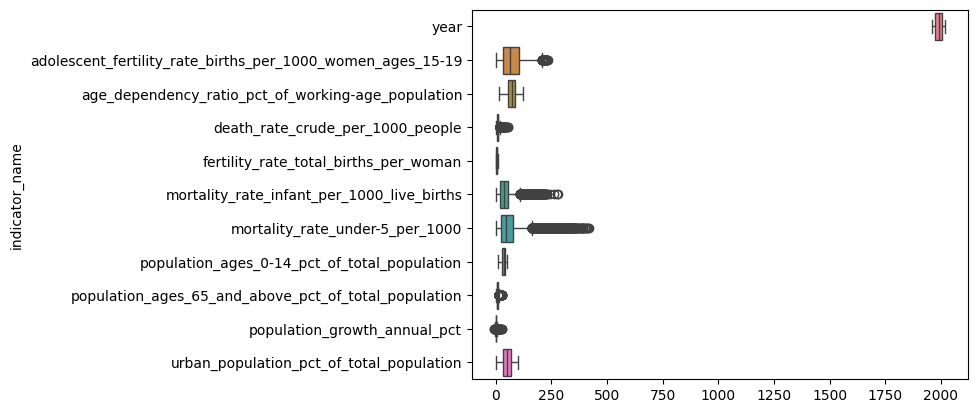

In [80]:
'''
    Visualisasi boxplot untuk mendeteksi outlier sebelum
    dihandle.
'''
sns.boxplot(data=X_train, orient='h')

Berdasarkan informasi di atas,
1. Fitur yang Distribusinya Normal
- `year`: -0.02
- `age_dependency_ratio_pct_of_working-age_population`: 0.08
- `fertility_rate_total_births_per_woman`: 0.42
- `population_ages_0-14_pct_of_total_population`: -0.51
- `urban_population_pct_of_total_population`: 0.11

2. Fitur yang memiliki *Skew*
- `adolescent_fertility_rate_births_per_1000_women_ages_15-19`: 0.83

3. Fitur yang memiliki *Extreme Skew*
- `death_rate_crude_per_1000_people`: 1.74
- `mortality_rate_infant_per_1000_live_births`: 1.65
- `mortality_rate_under-5_per_1000`: 1.92
- `population_ages_65_and_above_pct_of_total_population`: 1.48
- `population_growth_annual_pct`: 2.54

Untuk fitur yang distribusinya normal, perlu melakukan *handle outlier* menggunakan `Z-Score`. Sementara untuk fitur *skew*, menggunakan metode IQR dengan *multiplier* 1.5 dan fitur *extreme skew* menggunakan metode IQR dengan *multiplier* 3. Pendekatan ini dipilih agar data menjadi lebih stabil tanpa menghilangkan terlalu banyak informasi penting.

In [81]:
'''
    Membersihkan outlier dari kolom year, age_dependency_ratio_pct_of_working-age_population,
    fertility_rate_total_births_per_woman, population_ages_0-14_pct_of_total_population, dan
    urban_population_pct_of_total_population dengan mengnggunakan z-score. Kemudian menentukan 
    batas bawah dan batas atas dengan multipier 3. Lalu clip() nilai < lower menjadi lower dan 
    nilai > upper menjadi upper untuk label nilai ekstrem.
'''
normal_cols = [
    'year', 'age_dependency_ratio_pct_of_working-age_population',
    'fertility_rate_total_births_per_woman', 'population_ages_0-14_pct_of_total_population',
    'urban_population_pct_of_total_population'
]

for col in normal_cols:
    avg = X_train[col].mean()
    std = X_train[col].std()

    lower = avg - 3 * std
    upper = avg + 3 * std

    # clip outlier
    X_train[col] = X_train[col].clip(lower, upper)

In [82]:
'''
    Membersihkan outlier dari kolom adolescent_fertility_rate_births_per_1000_women_ages_15-19 
    dengan menghitung IQR. Kemudian menentukan batas bawah dan batas atas dengan multipier 1.5. 
    Lalu clip() nilai < lower menjadi lower dan nilai > upper menjadi upper untuk label
    nilai skew.
'''

outlier_cols = [
    'adolescent_fertility_rate_births_per_1000_women_ages_15-19'
]

for col in outlier_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X_train[col] = X_train[col].clip(lower, upper)

In [83]:
'''
    Membersihkan outlier dari kolom death_rate_crude_per_1000_people, 
    mortality_rate_infant_per_1000_live_births, mortality_rate_under-5_per_1000, 
    population_ages_65_and_above_pct_of_total_population, dan population_growth_annual_pct 
    dengan menghitung IQR. Kemudian menentukan batas bawah dan batas atas dengan multipier 3. 
    Lalu clip() nilai < lower menjadi lower dan nilai > upper menjadi upper untuk label
    nilai extreme skew.
'''

extreme_outlier_cols = [
    'death_rate_crude_per_1000_people', 'mortality_rate_infant_per_1000_live_births', 
    'mortality_rate_under-5_per_1000', 'population_ages_65_and_above_pct_of_total_population',
    'population_growth_annual_pct'
]

for col in extreme_outlier_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR

    X_train[col] = X_train[col].clip(lower, upper)

<Axes: ylabel='indicator_name'>

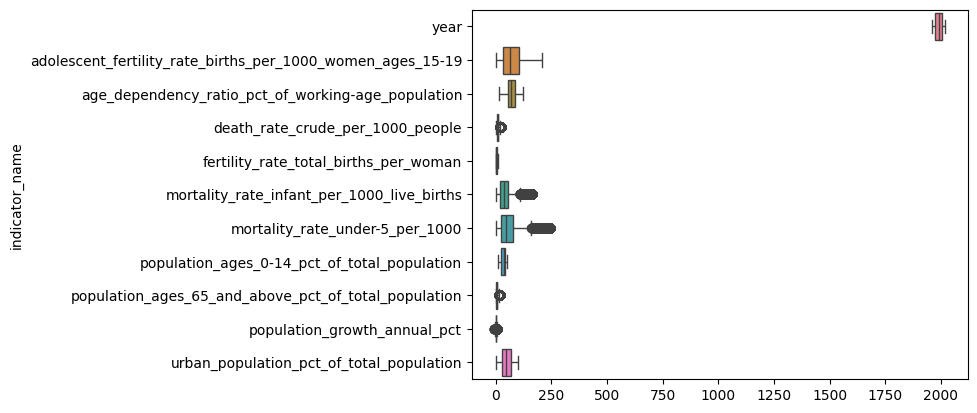

In [84]:
'''
    Visualisasi boxplot untuk mendeteksi outlier setelah
    dihandle.
'''
sns.boxplot(data=X_train, orient='h')

In [85]:
'''
    Mengecek apakah distribusi jadi lebih normal setelah outlier
    handling.
'''

X_train.skew(numeric_only=True)


indicator_name
year                                                         -0.001605
adolescent_fertility_rate_births_per_1000_women_ages_15-19    0.803295
age_dependency_ratio_pct_of_working-age_population            0.078464
death_rate_crude_per_1000_people                              1.369689
fertility_rate_total_births_per_woman                         0.420136
mortality_rate_infant_per_1000_live_births                    1.429510
mortality_rate_under-5_per_1000                               1.560326
population_ages_0-14_pct_of_total_population                 -0.509361
population_ages_65_and_above_pct_of_total_population          1.448715
population_growth_annual_pct                                  0.792512
urban_population_pct_of_total_population                      0.109605
dtype: float64

Berdasarkan *output* di atas, semua distribusi sudah lebih stabil dan *outlier* ekstrem sudah berkurang tetapi masih tergolong *skewed*. Oleh karena itu, tahap selanjutnya adalah *scaling* menggunakan `StandardScaler`.

## **Feature Selection**

Tahap ini **mengetahui fitur mana yang memiliki hubungan kuat dengan target (`health_status`)**.

In [86]:
'''
    Menggabungkan data X_train dan y_train
'''

concat_train = pd.concat([X_train, y_train], axis=1)
concat_train.head()

,country_name,year,region,income_group,adolescent_fertility_rate_births_per_1000_women_ages_15-19,age_dependency_ratio_pct_of_working-age_population,death_rate_crude_per_1000_people,fertility_rate_total_births_per_woman,mortality_rate_infant_per_1000_live_births,mortality_rate_under-5_per_1000,population_ages_0-14_pct_of_total_population,population_ages_65_and_above_pct_of_total_population,population_growth_annual_pct,urban_population_pct_of_total_population,health_status
3978,Faroe Islands,1975,Europe & Central Asia,High income,63.4908,71.269403,6.900,2.900,35.8,45.4,37.260537,4.384734,1.083540,30.326,0
3314,Djibouti,1981,Middle East & North Africa,Lower middle income,52.8626,95.121621,11.899,6.513,113.9,149.9,46.372324,2.377466,4.353905,73.028,0
6714,Lebanon,1968,Middle East & North Africa,Lower middle income,76.0946,92.174274,8.490,5.181,48.3,62.9,42.829790,5.134089,1.643498,56.101,0
12775,Vanuatu,1994,East Asia & Pacific,Lower middle income,66.6792,86.742519,6.731,4.754,25.3,30.4,42.987528,3.462520,2.708034,19.868,0
8863,North Macedonia,1984,Europe & Central Asia,Upper middle income,50.0084,51.772033,7.349,2.399,46.2,50.9,27.999787,6.111937,0.432505,55.276,1


In [87]:
'''
    Melihat kolom di concat_train
'''

concat_train.columns

Index(['country_name', 'year', 'region', 'income_group',
       'adolescent_fertility_rate_births_per_1000_women_ages_15-19',
       'age_dependency_ratio_pct_of_working-age_population',
       'death_rate_crude_per_1000_people',
       'fertility_rate_total_births_per_woman',
       'mortality_rate_infant_per_1000_live_births',
       'mortality_rate_under-5_per_1000',
       'population_ages_0-14_pct_of_total_population',
       'population_ages_65_and_above_pct_of_total_population',
       'population_growth_annual_pct',
       'urban_population_pct_of_total_population', 'health_status'],
      dtype='object')

In [88]:
'''
    Membuat function untuk menghitung korelasi variabel dengan
    target menggunakan phik.
'''

def compute_phik_correlation(dataframe, columns, target):
    subset = dataframe[columns + [target]]
    correlation_matrix = subset.phik_matrix()
    return correlation_matrix[target]


columns = [
    'country_name', 'year', 'region', 'income_group',
    'adolescent_fertility_rate_births_per_1000_women_ages_15-19',
    'age_dependency_ratio_pct_of_working-age_population',
    'death_rate_crude_per_1000_people', 'fertility_rate_total_births_per_woman',
    'mortality_rate_infant_per_1000_live_births', 'mortality_rate_under-5_per_1000',
    'population_ages_0-14_pct_of_total_population',
    'population_ages_65_and_above_pct_of_total_population',
    'population_growth_annual_pct', 'urban_population_pct_of_total_population'
]
target = 'health_status'

correlation = compute_phik_correlation(concat_train, columns, target)
print(correlation)

interval columns not set, guessing: ['year', 'adolescent_fertility_rate_births_per_1000_women_ages_15-19', 'age_dependency_ratio_pct_of_working-age_population', 'death_rate_crude_per_1000_people', 'fertility_rate_total_births_per_woman', 'mortality_rate_infant_per_1000_live_births', 'mortality_rate_under-5_per_1000', 'population_ages_0-14_pct_of_total_population', 'population_ages_65_and_above_pct_of_total_population', 'population_growth_annual_pct', 'urban_population_pct_of_total_population', 'health_status']
country_name                                                  0.887577
year                                                          0.400423
region                                                        0.471268
income_group                                                  0.709319
adolescent_fertility_rate_births_per_1000_women_ages_15-19    0.815775
age_dependency_ratio_pct_of_working-age_population            0.906277
death_rate_crude_per_1000_people                          

Berdasarkan informasi di atas, tidak ada korelasi bernilai 0 dan seluruh kolom cukup berkesinambungan dengan target. Menurut saya, seluruh fitur akan dipilih untuk ke tahap selanjutnya.

## **Frequency Encoding `country_name`**

In [89]:
'''
    Menghitung frekuensi (persentase) dari country_name. Lalu mengubah 
    data kategori menjadi angka frekuensi. Mapping keduanya ke dalam 
    data train dan test.
'''

high_cardinality_columns = ['country_name']

country_name_freq = X_train['country_name'].value_counts(normalize=True)

X_train['country_name_freq'] = X_train['country_name'].map(country_name_freq)
X_test['country_name_freq'] = X_test['country_name'].map(country_name_freq).fillna(0)

X_train.drop(columns=high_cardinality_columns, inplace=True)
X_test.drop(columns=high_cardinality_columns, inplace=True)

## **Split Numerical Columns and Categorical Columns FINAL**

Tahap ini melakukan **pemisahan fitur numerik, fitur kategorikal dengan urutan, dan fitur kategorikal tanpa urutan** sebelum melakukan *scaling* dan *encoding* di tahap *preprocessing*. 

In [90]:
'''
    Memisahkan kolom menjadi 3 kategori, yaitu num_cols yang 
    berisi kategori angka, ohe_cols yang berisi kategori string
    tanpa urutan, dan ordinal_cols yang berisi kategori string
    dengan urutan.
'''

num_cols = [
    'year', 'adolescent_fertility_rate_births_per_1000_women_ages_15-19',
    'age_dependency_ratio_pct_of_working-age_population', 
    'death_rate_crude_per_1000_people', 'fertility_rate_total_births_per_woman',
    'mortality_rate_infant_per_1000_live_births', 'mortality_rate_under-5_per_1000',
    'population_ages_0-14_pct_of_total_population', 
    'population_ages_65_and_above_pct_of_total_population',
    'population_growth_annual_pct', 'urban_population_pct_of_total_population', 
    'country_name_freq'
]

ohe_cols = ['region']

ordinal_cols = ['income_group']

## **Preprocessing**

In [91]:
income_order = [
    ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
]

preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_cols),
    ('ohe', OneHotEncoder(handle_unknown='ignore'), ohe_cols),
    ('ord', OrdinalEncoder(categories=income_order), ordinal_cols)
])

Preprocessing yang digunakan meliputi:
- Normalisasi fitur numerik menggunakan `MinMaxScaler`
- Encoding fitur kategorikal menggunakan `OneHotEncoder` untuk variabel `region` dan `OrdinalEncoder` untuk variabel `income_group` berdasarkan tingkatan ekonomi.

# **BAB 6. Model Definition**

Langkah selanjutnya adalah **Model Definition**. Langkah ini merupakan proses untuk menyelesaikan permasalahan klasifikasi status kesehatan. Setiap model diintegrasikan dengan *preprocessing* menggunakan pipeline untuk memastikan seluruh proses berjalan secara konsisten dan menghindari data *leakage*. Proses ini membandingkan model **`K-Nearest Neighbors`**, **`Support Vector Machine`**, **`Decision Tree Classifier`**, **`Random Forest`**, dan **`Gradient Boosting`**.

## **K-Nearest Neighbors (KNN)**

In [92]:
model_kneighbors =  KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',
    algorithm='auto',
    leaf_size=30,
    p=2,
    metric='minkowski'
)

**`K-Nearest Neighbors (KNN)`** merupakan salah satu algoritma *Machine Learning* berbasis jarak yang mengklasifikasikan data berdasarkan kedekatan dengan data lain. Cara kerjanya adalah menentukan kelas suatu data dengan melihat mayoritas kelas dari k terdekat.

Alasan memilih **`K-Nearest Neighbors`**, yaitu:
1. Sederhana dan mudah diimplementasikan.
2. Tidak membutuhkan asumsi distribusi data.
3. Cocok untuk data yang telah dinormalisasi.

*Hyperparameter* yang dipakai:
- `n_neighbors=5`    
Digunakan sebagai penentu seberapa banyak tetangga.
- `weights='uniform'`   
Digunakan sebagai menghitung pengaruh tetangga, `uniform` artinya semua pengaruh sama.
- `algorithm='auto'`    
Digunakan sebagai metode pencarian tetangga terdekat secara *automatic*.
- `leaf_size=30`    
Digunakan sebagai pengaruh kecepatan pencarian tetangga.
- `p=2`    
Digunakan sebagai penentuan jenis perhitungan, yaitu  euclidean (jarak lurus).
- `metric='minkowski'`   
Digunakan untuk menghitung jarak.

## **Support Vector Machine (SVM)**

In [93]:
model_support_vector_machine = SVC(
    C=1.0,
    kernel='rbf',
    degree=3,
    gamma='scale',
    coef0=0.0
)

**`Support Vector Machine (SVM)`** merupakan salah satu algoritma *Machine Learning* yang bekerja dengan mencari *hyperplane* terbaik yang memisahkan kelas dengan margin maksimum. 

Alasan memilih **`Support Vector Machine`**, yaitu:
1. Efektif untuk data dengan dimensi tinggi.
2. Mampu menangani *boundary* non-linear (dengan kernel).

*Hyperparameter* yang dipakai:
- `C=1.0`   
Digunakan sebagai pengontrol regularisasi.
- `kernel='rbf'`   
Digunakan sebagai pembentuk *boundary* yang bisa melengkung.
- `degree=3`    
Digunakan sebagai kernel polynomial.
- `gamma='scale'`     
Digunakan sebagai mengukur seberapa jauh pengaruh satu titik.
- `coef0=0.0`   
Digunakan sebagai konstanta independen dalam fungsi kernel.

## **Decision Tree Classifier**

In [94]:
model_decision_tree = DecisionTreeClassifier(
    criterion='gini',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)

**`Decision Tree Classifier`** merupakan salah satu algoritma *Machine Learning* yang bekerja dengan cara membangun model berbasis aturan keputusan berbentuk pohon (*tree structure*) dengan membagi data secara rekursif berdasarkan fitur yang paling informatif.

Alasan memilih **`Decision Tree Classifier`**, yaitu:
1. Mampu menangkap hubungan non-linear.
2. Tidak membutuhkan asumsi distribusi data.
3. Mudah dipahami karena berbasis aturan (tree structure).

*Hyperparameter* yang dipakai:
- `criterion='gini'`   
Digunakan sebagai cara memilih *split* terbaik.
- `splitter='best'`   
Digunakan sebagai penentuan cara memilih *split* pada setiap *node*.
- `max_depth=None`    
Digunakan sebagai kedalaman *tree*.
- `min_samples_split=2`    
Digunakan sebagai minimal data untuk *split*.
- `min_samples_leaf=1`    
Digunakan sebagai minimal data di *leaf*.

## **Random Forest**

In [95]:
model_random_forest = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt'
)

**`Random Forest`** merupakan salah satu algoritma *Machine Learning* yang bekerja menggunakan metode *ensemble* dengan menggabungkan banyak *decision tree*.

Alasan memilih **`Random Forest`**, yaitu:
1. Mengurangi overfitting.
2. Lebih stabil dibanding *decision tree* tunggal.

*Hyperparameter* yang dipakai:
- `n_estimators=100`   
Digunakan sebagai jumlah *tree*.
- `criterion='gini'`    
Digunakan sebagai cara memilih *split* terbaik.
- `max_depth=None`    
Digunakan sebagai kedalaman tiap *tree*.
- `min_samples_split=2`   
Digunakan sebagai minimal data untuk *split*.
- `min_samples_leaf=1`   
Digunakan sebagai minimal data di *leaf*.
- `max_features='sqrt'`   
Digunakan sebagai jumlah fitur tiap *split*.

## **Gradient Boosting**

In [96]:
model_gradient_boosting = GradientBoostingClassifier(
    loss='log_loss',
    learning_rate=0.1,
    n_estimators=100,
    max_depth=3
)

**`Gradient Boosting`** merupakan salah satu algoritma *Machine Learning* yang membangun model secara bertahap dengan cara memperbaiki kesalahan model sebelumnya, sehingga menghasilkan performa yang lebih baik.

Alasan memilih **`Gradient Boosting`**, yaitu:
1. Meningkatkan performa model
2. Mampu menangkap pola kompleks

*Hyperparameter* yang dipakai:
- `loss='log_loss'`    
Digunakan sebagai fungsi *loss* yang dioptimalkan selama *training*.
- `learning_rate=0.1`   
Digunakan sebagai seberapa cepat model belajar.
- `n_estimators=100`    
Digunakan sebagai jumlah iterasi *boosting*
- `max_depth=3`   
Digunakan sebagai kedalaman *tree*.

## **Jenis Metrics**

1. **`Precision`**   
`Precision` digunakan sebagai metric utama untuk meminimalisir kesalahan dalam mengklasifikasikan data dengan kondisi kesehatan rendah menjadi tinggi (False Positive). Selain itu, `Precision` digunakan untuk mengukur kemampuan model dalam memprediksi seberapa akurat nilai positif yang dihasilkan oleh model.

2. **`ROC-AUC Score`**   
`ROC-AUC Score` digunakan untuk mengukur kemampuan model dalam membedakan antara kelas positif dan negatif. Semakin tinggi nilai `ROC-AUC`, semakin baik kemampuan model dalam melakukan klasifikasi. Metric ini dipilih karena tidak bergantung pada threshold tertentu dan mampu memberikan gambaran performa model secara keseluruhan, terutama pada dataset yang tidak seimbang.

# **BAB 7. Model Training**

Langkah selanjutnya adalah **Model Training**. Langkah ini melatih model *machine learning* menggunakan data training untuk mempelajari pola hubungan antara fitur dan target. Preprocessing dan model digabungkan dengan pipeline untuk memastikan konsistensi transformasi data dan menghindari *data leakage*. Setiap model akan dilatih menggunakan parameter *default* sebagai *baseline* sebelum dilakukan evaluasi lebih lanjut menggunakan `Cross Validation` dan `Hyperparameter Tuning`.

## **Pipeline**

`Pipeline` digunakan untuk menggabungkan *preprocessing* dan model dalam satu alur kerja. Alasan menggunakan `pipeline` adalah menghindari *data leakage*, menjamin konsistensi *preprocessing*, dan mempermudah proses *model training*.

In [97]:
pipe_kneighbors = Pipeline([
    ('preprocessing', preprocessor),
    ('model', model_kneighbors)
])
pipe_kneighbors.fit(X_train, y_train)

pipe_support_vector_machine = Pipeline([
    ('preprocessing', preprocessor),
    ('model',model_support_vector_machine)
])
pipe_support_vector_machine.fit(X_train, y_train)

pipe_decision_tree = Pipeline([
    ('preprocessing', preprocessor),
    ('model', model_decision_tree)
])
pipe_decision_tree.fit(X_train, y_train)

pipe_random_forest = Pipeline([
    ('preprocessing', preprocessor),
    ('model', model_random_forest)
])
pipe_random_forest.fit(X_train, y_train)

pipe_gradient_boosting = Pipeline([
    ('preprocessing', preprocessor),
    ('model', model_gradient_boosting)
])
pipe_gradient_boosting.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['year',
                                                   'adolescent_fertility_rate_births_per_1000_women_ages_15-19',
                                                   'age_dependency_ratio_pct_of_working-age_population',
                                                   'death_rate_crude_per_1000_people',
                                                   'fertility_rate_total_births_per_woman',
                                                   'mortality_rate_infant_per_1000_live_births',
                                                   'mortality_rate_under...
                                                   'population_ages_65_and_above_pct_of_total_population',
                                                   'population_growth_annual_pct',
                                                   'urban_population_pct_of_total_population',
                                                   'country_name_freq']),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['region']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Low '
                                                                              'income',
                                                                              'Lower '
                                                                              'middle '
                                                                              'income',
                                                                              'Upper '
                                                                              'middle '
                                                                              'income',
                                                                              'High '
                                                                              'income']]),
                                                  ['income_group'])])),
                ('model', GradientBoostingClassifier())])

## **Cross Validation**

**`Cross validation`** merupakan teknik evaluasi model dengan cara membagi data menjadi beberapa bagian (*fold*). Model akan dilatih dan diuji secara bergantian pada setiap bagian. Tujuannya adalah menghindari bias dari satu kali *split*, mengukur performa model secara lebih akurat, dan menilai stabilitas model. 

Pada tahap ini, akan menggunakan **5-fold cross validation**, model dilatih dan diuji secara bergantian pada setiap fold. Kemudian hasilnya dirata-ratakan untuk mendapatkan performa yang lebih representatif.

In [98]:
models = {
    'K-Nearest Neighbors': pipe_kneighbors,
    'Support Vector Machine': pipe_support_vector_machine,
    'Decision Tree Classifier': pipe_decision_tree,
    'Random Forest': pipe_random_forest,
    'Gradient Boosting': pipe_gradient_boosting
}

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='precision',error_score='raise')
    
    cv_results[name] = {
        'mean': scores.mean(),
        'std': scores.std()
    }

cv_results

{'K-Nearest Neighbors': {'mean': 0.9610156970124238,
  'std': 0.0035374172178921533},
 'Support Vector Machine': {'mean': 0.9418828939326586,
  'std': 0.004412755412754336},
 'Decision Tree Classifier': {'mean': 0.9650670435906858,
  'std': 0.004758882479226993},
 'Random Forest': {'mean': 0.9812047118437068, 'std': 0.004706916856750963},
 'Gradient Boosting': {'mean': 0.9638322946956135,
  'std': 0.004386482605432843}}

Berikut merupakan hasil dari **5-fold cross validation** yang menguji 5 model:
- **`Random Forest` dengan nilai mean yaitu 0.98 dan nilai std yaitu 0.0047**.
- `Decision Tree Classifier` dengan nilai mean yaitu 0.97 dan nilai std yaitu 0.0047.
- `Gradient Boosting` dengan nilai mean yaitu 0.96 dan nilai std yaitu 0.0044.
- `K-Nearest Neighbors` dengan nilai mean yaitu 0.96 dan nilai std yaitu 0.0035.
- `Support Vector Machine` dengan nilai mean yaitu 0.94 dan nilai std yaitu 0.0044.

Model terbaik adalah **`Random Forest`** karena memiliki nilai `precision` tertinggi dengan **0.98 atau 98% prediksi itu benar**. Hal ini dapat diartikan bahwa model ini dapat meminimalisir kesalahan prediksi seperti memprediksi tingkat kesehatan rendah padahal data aktualnya tinggi. Model ini juga menunjukkan nilai standar deviasi yang rendah (<0.01), sehingga adanya indikasi bahwa performa model stabil dan konsisten pada setiap *fold*. Maka dari itu, **`Random Forest`** dipilih sebagai model terbaik untuk tahap selanjutnya yaitu `Hyperparameter Tuning`.

## **Hyperparameter Tuning**

**`Hyperparameter Tuning`** merupakan proses mencari kombinasi *hyperparameter* terbaik dari hasil `Cross Validation` menggunakan `GridSearchCV` dengan tujuan untuk meningkatkan performa model.

In [99]:
'''
    Mencoba semua kombinasi parameter menggunakan GridSearchCV
    dengan beberapa parameter, seperti C, penalty, dan solver.
    Set up GridSearch dengan:
    - estimator sebagai model yang akan dituning.
    - param_grid sebagai parameter yang akan dicoba.
    - scoring sebagai metric utama.
    - cv/cross validation sebagai pembagian data.
    - n_jobs sebagai penggunaan seluruh core CPU.
    - verbose sebagai jumlah kombinasi parameter.

    Kemudian GridSearch ditraining dan mengambil model terbaik.
'''

# param grid
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 5],
    'model__max_features': ['sqrt', 'log2']
}

# grid search
grid_search = GridSearchCV(
    estimator=pipe_random_forest,
    param_grid=param_grid,
    cv=5,
    scoring='precision',
    n_jobs=-1,
    verbose=1
)

# training
grid_search.fit(X_train, y_train)

# best model
best_model_tuned = grid_search.best_estimator_

# best parameter
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'model__max_depth': 20, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best Score: 0.9812144143952434


Berdasarkan hasil *hyperparameter tuning*, diperoleh parameter terbaik yaitu **`max_depth=20`, `max_features='log2'`, `min_samples_leaf=1`,`min_samples_split=2`, dan `n_estimators=100`** dengan *score* 0.9812. 

Nilai `max_depth`cukup dalam tapi masih bisa menangkap pola kompleks, nilai `min_samples_leaf` kecil tapi cukup detail, dan nilai `n_estimators` sudah optimal menyebabkan model sudah stabil. Selain itu, `max_features` hanya memakai sebagian fitur tiap *split* menyebabkan generalisasi meningkat dan *overfitting* berkurang.

# **BAB 8. Model Evaluation**

Langkah selanjutnya adalah **Model Evaluation**. Langkah ini membandingkan performa model sebelum dan sesudah *tuning*. Pada langkah ini dilakukan evaluasi performa model menggunakan metrik `precision` dan `ROC-AUC`. 

Pemilihan metrik `precision` didasarkan pada tujuan utama, yaitu meminimalisir kesalahan dalam mengklasifikasikan data dengan kondisi kesehatan rendah sebagai tinggi (False Positive).

In [100]:
'''
    Membanding model sebelum tuning dan setelah tuning dengan
    memprediksi label (0/1) untuk precision dan mengambil 
    probabilitas kelas 1 (positif) untuk roc-auc.
'''

best_model_score = grid_search.best_score_
# BEFORE
y_pred_before = pipe_random_forest.predict(X_test)
y_proba_before = pipe_random_forest.predict_proba(X_test)[:, 1]

# AFTER
y_pred_after = best_model_tuned.predict(X_test)
y_proba_after = best_model_tuned.predict_proba(X_test)[:, 1]

precision_before = precision_score(y_test, y_pred_before)
precision_after = precision_score(y_test, y_pred_after)

roc_before = roc_auc_score(y_test, y_proba_before)
roc_after = roc_auc_score(y_test, y_proba_after)

print("BEFORE TUNING")
print(f"Precision: {precision_before:.4f} | ROC-AUC: {roc_before:.4f}")

print("\nAFTER TUNING")
print(f"Precision: {precision_after:.4f} | ROC-AUC: {roc_after:.4f}")

BEFORE TUNING
Precision: 0.9781 | ROC-AUC: 0.9971

AFTER TUNING
Precision: 0.9791 | ROC-AUC: 0.9975


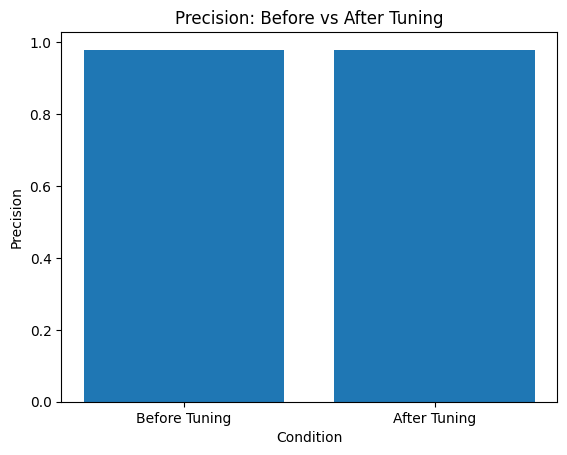

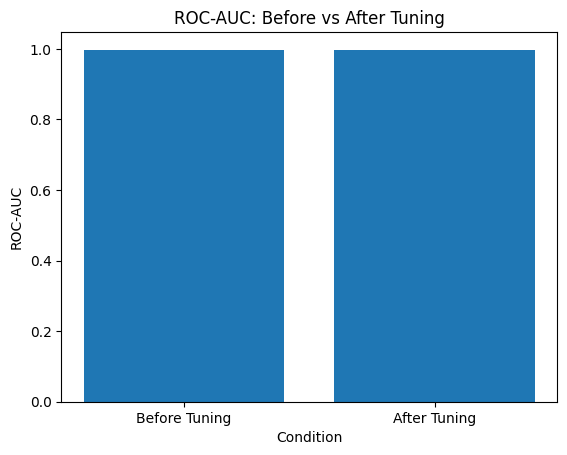

In [101]:
'''
    Membuat dictionary untuk simpan hasil metrics sebelum
    dan setelah tuning. Lalu visualisasi hasil dengan bar chart.
'''

data = {
    "Condition": ["Before Tuning", "After Tuning"],
    "Precision": [precision_before, precision_after],
    "ROC_AUC": [roc_before, roc_after]
}

df_eval = pd.DataFrame(data)

# Plot Recall
plt.figure()
plt.bar(df_eval["Condition"], df_eval["Precision"])
plt.title("Precision: Before vs After Tuning")
plt.xlabel("Condition")
plt.ylabel("Precision")
plt.show()

# Plot ROC-AUC
plt.figure()
plt.bar(df_eval["Condition"], df_eval["ROC_AUC"])
plt.title("ROC-AUC: Before vs After Tuning")
plt.xlabel("Condition")
plt.ylabel("ROC-AUC")
plt.show()

Berdasarkan hasil evaluasi, performa model **`Random Forest`** setelah dilakukan `Hyperparameter Tuning` **mengalami perubahan dengan sedikit membaik**. 

Nilai `Precision` meningkat dari **0.9781 menjadi 0.9791**. Hal ini menunjukkan bahwa model semakin baik dalam mendeteksi kelas positif. Sementara itu, nilai `ROC-AUC` meningkat dari **0.9971 menjadi 0.9975**. Nilai ini mendekati 1 sehingga menunjukkan bahwa model memiliki kemampuan yang sangat baik dalam membedakan kedua kelas.

Hal tersebut menunjukkan bahwa model `Random Forest` dengan parameter default sudah memiliki performa yang sangat baik karena peningkatan performa tidak terlalu signifikan. `Hyperparameter Tuning` memberikan peningkatan kecil namun tetap meningkatkan kualitas model secara keseluruhan.

Dengan demikian, model yang akan saya pilih adalah **model `Random Forest` hasil tuning** karena telah melalui proses *cross-validation* sehingga lebih *robust* terhadap variasi data.

## **Feature Importance Based on Best Model**

In [102]:
importances = best_model_tuned.named_steps['model'].feature_importances_
feature_names = best_model_tuned.named_steps['preprocessing'].get_feature_names_out()

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp

,feature,importance
4,num__fertility_rate_total_births_per_woman,0.210818
7,num__population_ages_0-14_pct_of_total_population,0.157425
2,num__age_dependency_ratio_pct_of_working-age_p...,0.097043
6,num__mortality_rate_under-5_per_1000,0.096738
3,num__death_rate_crude_per_1000_people,0.094506
5,num__mortality_rate_infant_per_1000_live_births,0.091065
8,num__population_ages_65_and_above_pct_of_total...,0.088473
1,num__adolescent_fertility_rate_births_per_1000...,0.047239
10,num__urban_population_pct_of_total_population,0.029008
0,num__year,0.024306


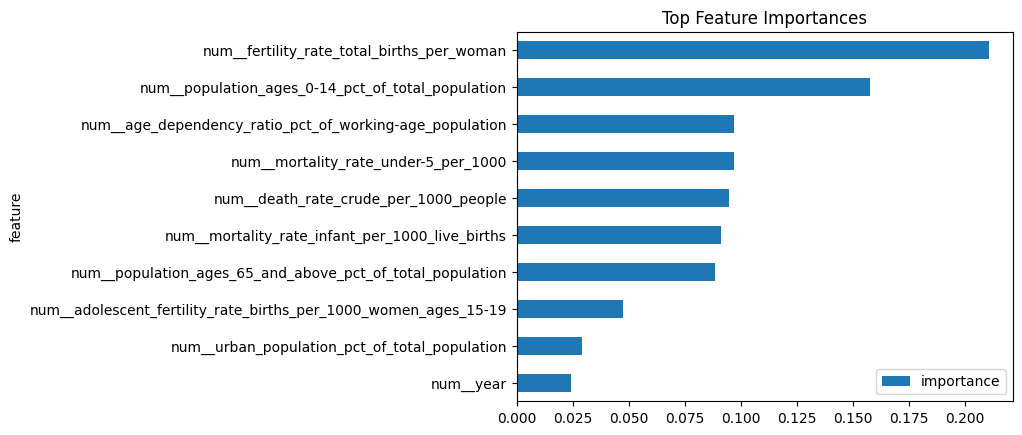

In [103]:
feat_imp.head(10).plot(
    kind='barh',
    x='feature',
    y='importance'
)

plt.gca().invert_yaxis()
plt.title('Top Feature Importances')
plt.show()

Fitur yang paling berpengaruh terhadap *best model*:
1. **`Fertility Rate`: 0.21**   
Tingkat kelahiran sangat mempengaruhi status kesehatan suatu negara, sehingga negara dengan angka kelahiran tinggi, tingkat kesehatannya cenderung lebih rendah.
2. **`Population Ages 0–14`: 0.16**   
Proporsi anak dari usia 0-14 cukup tinggi yang menyebabkan tingginya beban ekonomi dan besarnya kebutuhan kesehatan, sehingga tingkat kesehatannya cenderung lebih rendah.
3. **`Age Dependendy Ratio`: 0.097**   
Angka produktif cukup tinggi, semakin baik dampaknya untuk tingkat kesehatan di tempat tersebut.

Berdasarkan hasil *feature importance*, variabel yang paling berpengaruh terhadap status kesehatan adalah `fertility rate`, `population ages 0–14`, dan `age dependendy ratio`. Hal ini menunjukkan bahwa kondisi demografi dan tingkat kelahiran memiliki pengaruh besar terhadap kesehatan suatu negara. Sementara itu, `region` dan `year` memiliki pengaruh yang relatif kecil, sehingga mengindikasikan bahwa faktor demografi lebih dominan dibandingkan faktor geografis atau temporal.

# **BAB 9. Model Saving**

Langkah selanjutnya adalah **Model Saving**. Langkah ini menyimpan model terbaik yang telah dipilih berdasarkan hasil evaluasi pada tahap sebelumnya, model yang akan saya pilih adalah **Random Forest**. Model yang disimpan nantinya akan digunakan kembali pada proses *Model Inference* dan *Model Deployment*.

In [104]:
with open('best_model.pkl', 'wb') as file_best_model:
    pickle.dump(best_model_tuned, file_best_model)

with open('country_name_freq.pkl', 'wb') as file_country_freq:
    pickle.dump(country_name_freq, file_country_freq)

# preprocessing objects
with open('median_imputer.pkl', 'wb') as file_median_imputer:
    pickle.dump(median_imputer, file_median_imputer)

Berdasarkan hasil evaluasi pada tahap sebelumnya, model yang dipilih sebagai model terbaik adalah **`Random Forest`**. Model ini dipilih karena menunjukkan performa yang sangat baik dalam membedakan kedua kelas, yaitu **ROC-AUC yang mendekati 1**, serta didukung oleh nilai **Precision yang tinggi** sehingga mampu mengklasifikasikan kelas positif dengan akurat.

Selain itu, setelah dilakukan *Hyperparameter Tuning*, model **`Random Forest`** mengalami peningkatan performa meskipun tidak terlalu signifikan. Nilai **Precision meningkat dari 0.9781 menjadi 0.9791**, sedangkan **ROC-AUC meningkat dari 0.9971 menjadi 0.9975**. Hal ini menunjukkan bahwa model dengan parameter default sebenarnya sudah sangat baik, dan tuning hanya memberikan penyempurnaan kecil.

Dengan demikian, model yang digunakan adalah **`Random Forest` hasil tuning**, karena telah melalui proses *cross-validation* sehingga lebih **robust** terhadap variasi data dan memiliki generalisasi yang lebih baik.

Kelebihan **`Random Forest`**:
- Mampu menangkap hubungan non-linear antar fitur.
- Tidak terlalu sensitif terhadap *outlier* dan *noise*.
- Memiliki performa yang sangat tinggi (Precision>0.95 dan ROC-AUC mendekati 1).
- Lebih stabil karena merupakan metode *ensemble* (gabungan *decision tree*).

Kekurangan **`Random Forest`**:
- Kurang interpretable dibanding model linear.
- Membutuhkan waktu komputasi yang lebih besar.
- Rentan *overfitting* jika tidak dikontrol dengan baik.

Selain model utama, terdapat beberapa komponen preprocessing yang disimpan karena diperlukan saat model inference, yaitu:
- Frequency Encoding untuk `country_name` disimpan dalam `country_name_freq.pkl`
- Median Imputer disimpan dalam `median_imputer.pkl`

# **BAB 10. Model Inference**

Bab ini akan dikerjakan lebih lanjut dalam file **`P1M2_florean_alexander_inf.ipynb`**

# **BAB 11. Kesimpulan**

Berdasarkan keseluruhan proses yang telah dilakukan, mulai dari *data loading*, *exploratory data analysis*, *feature engineering*, *model definition*, *model training* hingga *model evaluation*, dapat disimpulkan bahwa tujuan utama penelitian ini **berhasil dicapai dengan baik**.

Pada tahap *Exploratory Data Analysis (EDA)*, ditemukan bahwa data awal memiliki permasalahan kualitas yang cukup signifikan, seperti adanya nilai tidak valid  yang mendominasi distribusi serta distribusi data yang sangat *skewed*. Setelah dilakukan proses *data cleaning*, pola distribusi menjadi lebih representatif dan memungkinkan analisis lebih lanjut. Hasil eksplorasi menunjukkan bahwa terdapat **ketimpangan kesehatan global yang cukup tinggi** karena negara dengan pendapatan tinggi, akses sanitasi yang baik, dan sistem kesehatan yang memadai cenderung memiliki **life expectancy** yang lebih tinggi dibandingkan negara berkembang.

Analisis indikator juga menunjukkan bahwa faktor **demografi dan kesehatan dasar** memiliki pengaruh yang signifikan terhadap status kesehatan suatu negara. Tingginya **fertility rate** dan **populasi usia muda (0–14 tahun)** cenderung memiliki status kesehatan yang rendah. Selain itu, indikator seperti **mortality rate (under-5)** menjadi sinyal kuat terhadap kualitas layanan kesehatan karena semakin tinggi angka kematian anak, semakin rendah tingkat kesehatan suatu negara. Hal ini menunjukkan bahwa indikator-indikator tersebut memiliki hubungan yang kuat dengan **life expectancy** dan relevan untuk digunakan dalam proses pemodelan.

Melalui proses selanjutnya, yaitu *Feature Engineering*. Terdapat beberapa proses komprehensif seperti *handling missing values*, *handling outlier*, dan *preprocessing*, kualitas data berhasil meningkat secara signifikan. 

Kemudian, dilakukan pembangunan model menggunakan beberapa algoritma *machine learning*, yaitu **K-Nearest Neighbors (KNN), Support Vector Machine (SVM), Decision Tree, Random Forest, dan Gradient Boosting**. Seluruh model diintegrasikan dengan *pipeline* untuk memastikan konsistensi preprocessing dan menghindari *data leakage*. Berdasarkan hasil *cross-validation*, model **Random Forest** menunjukkan performa terbaik dengan nilai **`Precision` sebesar 0.98** dan standar deviasi yang rendah. Hal tersebut menunjukkan bahwa model memiliki performa yang stabil dan konsisten.

Selanjutnya dilakukan proses *hyperparameter tuning* untuk mengoptimalkan performa model Random Forest. Hasil tuning menunjukkan adanya peningkatan performa meskipun tidak signifikan, di mana nilai **precision meningkat dari 0.9781 menjadi 0.9791** dan **ROC-AUC meningkat dari 0.9971 menjadi 0.9975**. Hal ini menunjukkan bahwa model baseline sudah sangat optimal, dan tuning berfungsi sebagai penyempurnaan akhir. 

Berdasarkan analisis *feature importance*, diketahui bahwa fitur yang paling berpengaruh dalam model adalah **fertility rate, population ages 0–14, dan mortality rate (under-5)**. Temuan ini konsisten dengan hasil EDA yang menunjukkan bahwa faktor demografi dan kesehatan dasar merupakan faktor utama dalam menentukan status kesehatan suatu negara, dibandingkan faktor geografis atau temporal.

Secara keseluruhan, objective dalam proyek ini telah berhasil dicapai. Model *machine learning* berhasil dikembangkan untuk mengklasifikasikan status kesehatan negara dengan performa yang sangat tinggi. Hubungan antara indikator kesehatan dan *life expectancy* berhasil diidentifikasi melalui analisis eksploratif dan *feature importance*. Selain itu, telah dilakukan perbandingan beberapa model untuk mendapatkan model terbaik. Model ini juga telah disimpan beserta komponen preprocessing sehingga siap digunakan untuk melakukan prediksi pada data baru maupun untuk tahap deployment.

## **Further Improvement**
> Menurut saya, hal yang perlu diperbaiki kedepannya adalah model dapat ditingkatkan melalui penambahan fitur( tingkat pendidikan, atau indeks pembangunan manusia), penggunaan algoritma lain (XGBoost, LightGBM, atau CatBoost), dan melakukan handling imbalanced data Lebih Lanjut.